## Decision-Motor RNN

Using device: cuda
Loading cached model and losses...
Loaded model with 200 training epochs


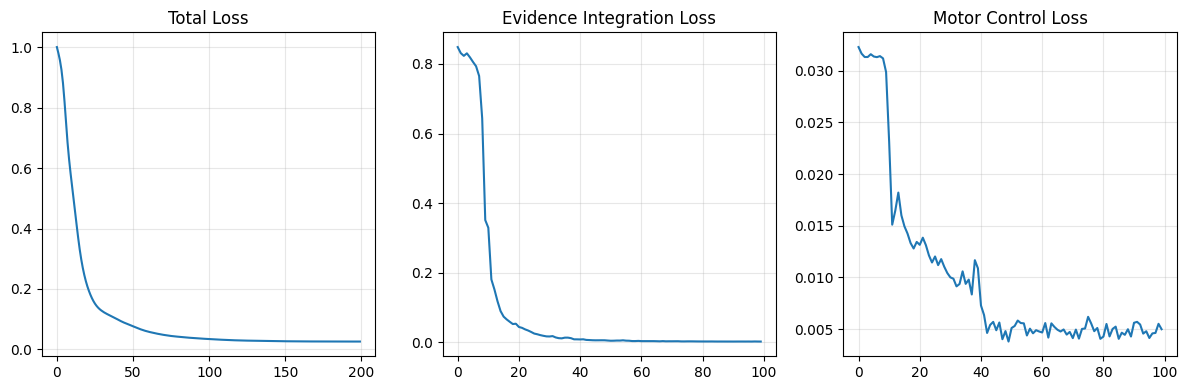

Analyzing your trained model...
Extracting trajectories from trained model...

Analyzing Evidence Region...
Evidence PCA explained variance: [0.8428029  0.11376742 0.02079944]


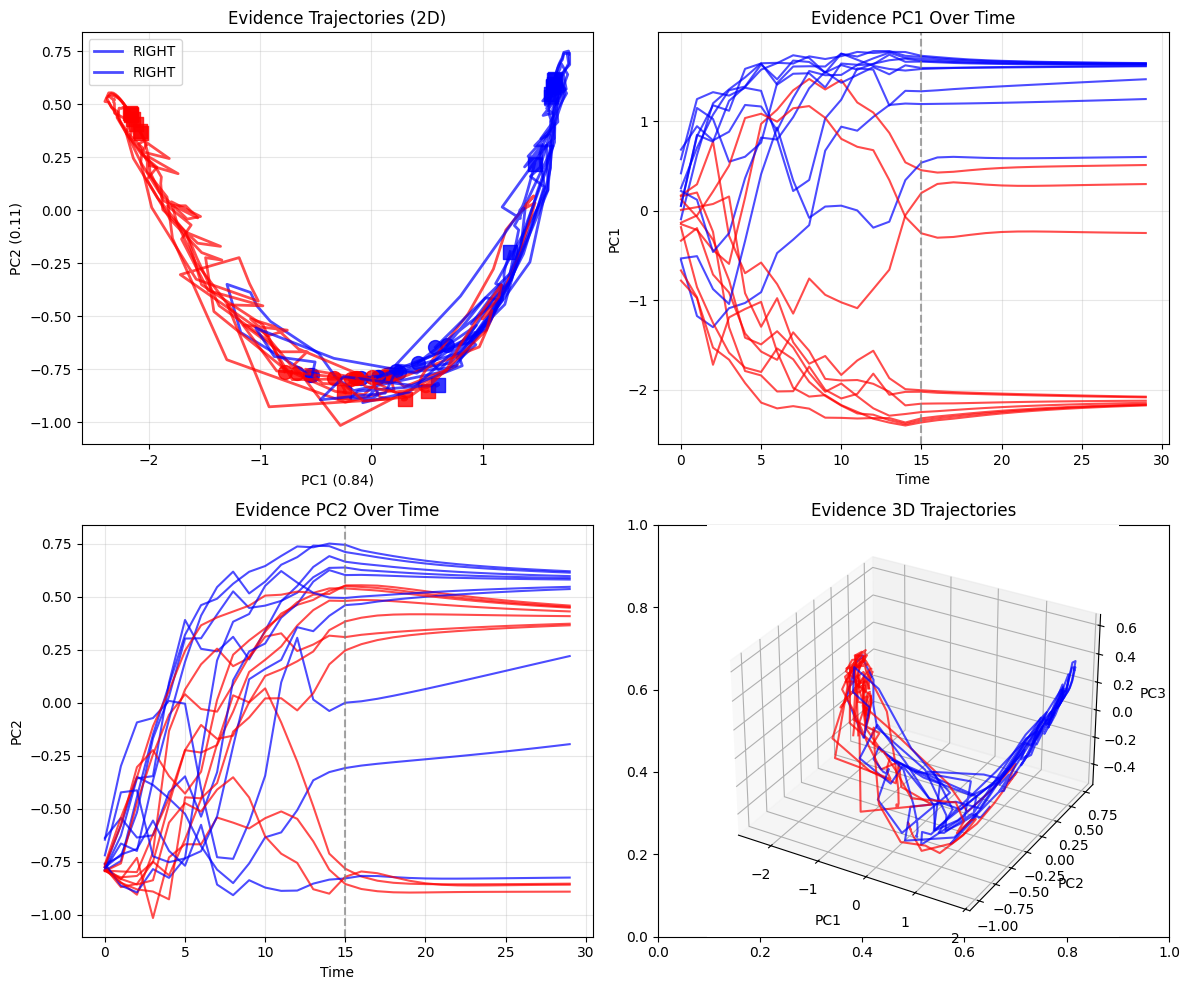


Analyzing Motor Region...
Motor PCA explained variance: [0.3541349  0.3184919  0.19507667]


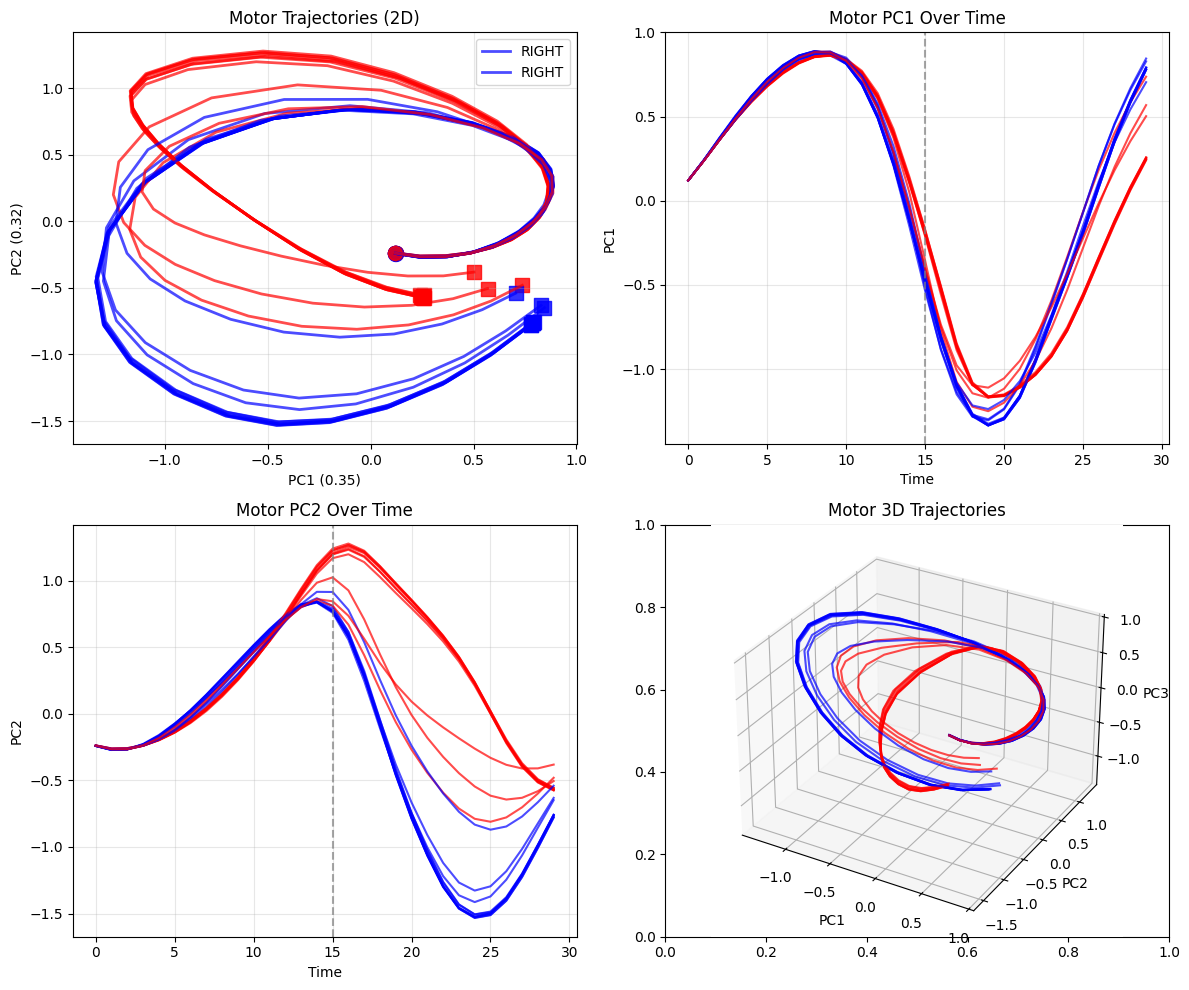


Analyzing Communication...


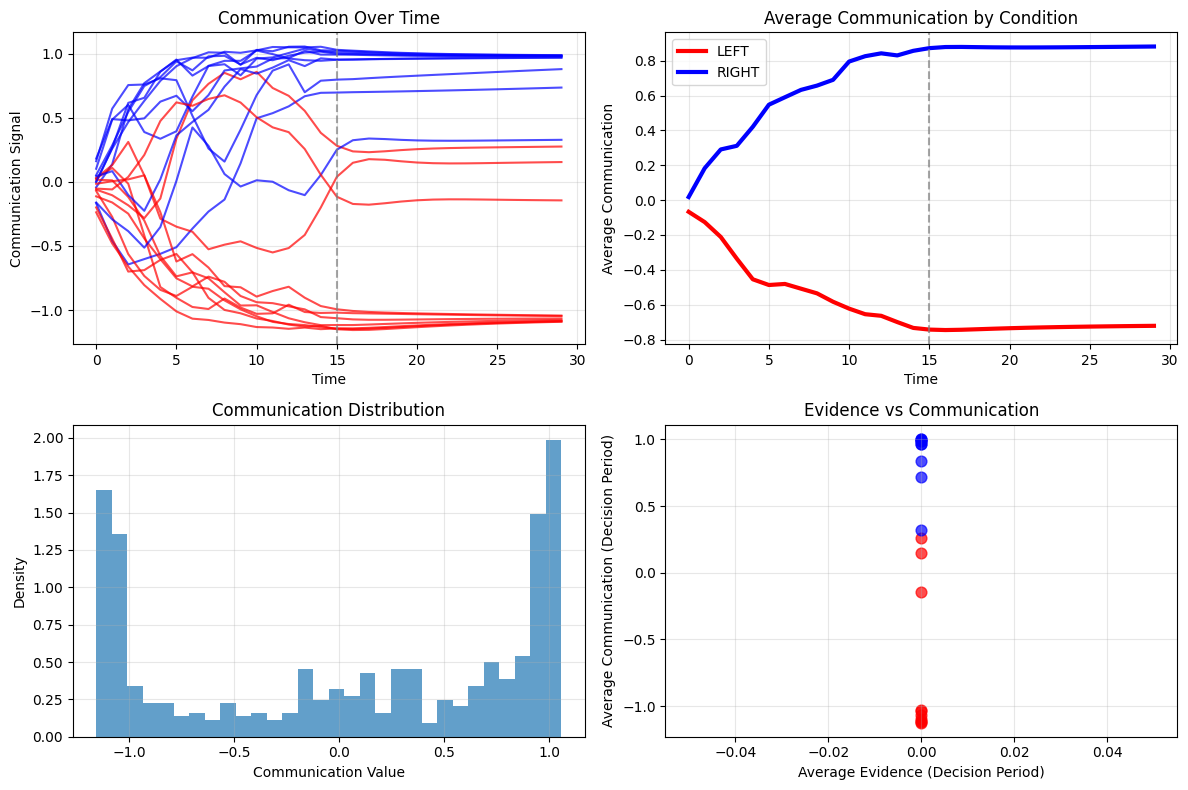

Training complete! Model saved as 'trained_model'


In [163]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns


# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Task parameters
SEQUENCE_LENGTH = 30
EVIDENCE_PHASE = 15  # First 40 steps have evidence
RESPONSE_STEP = 29   # Must be correct at step 49
BATCH_SIZE = 128
N_TRIALS = 1000
COHERENCE = 0.8      # Evidence strength
NOISE_LEVEL = 0.5    # Evidence noise

def generate_task_data(batch_size, sequence_length, coherence=0.3, noise_level=0.5):
    """Generate evidence integration + reaching task data"""
    
    # Random target direction for each trial (0=LEFT, 1=RIGHT)
    targets = torch.randint(0, 2, (batch_size,), device=device)
    
    # Evidence streams (first 40 timesteps)
    evidence = torch.zeros(batch_size, sequence_length, 2, device=device)
    evidence[:, :EVIDENCE_PHASE, 0] = (1 - targets.float()).unsqueeze(1) * coherence + \
                                      torch.randn(batch_size, EVIDENCE_PHASE, device=device) * noise_level
    evidence[:, :EVIDENCE_PHASE, 1] = targets.float().unsqueeze(1) * coherence + \
                                      torch.randn(batch_size, EVIDENCE_PHASE, device=device) * noise_level
    
    # True evidence integration (teaching signal for Region 1)
    true_integration = torch.cumsum(evidence[:, :, 1] - evidence[:, :, 0], dim=1)
    true_integration = torch.tanh(true_integration)  # Bounded integration
    
    # Target reach trajectories (teaching signal for Region 2)
    target_positions = torch.zeros(batch_size, sequence_length, 2, device=device)
    target_velocities = torch.zeros(batch_size, sequence_length, 2, device=device)
    
    for i in range(batch_size):
        if targets[i] == 0:  # LEFT reach
            target_positions[i, :, 0] = -1.0  # x = -1
            target_positions[i, :, 1] = 0.0   # y = 0
        else:  # RIGHT reach  
            target_positions[i, :, 0] = 1.0   # x = 1
            target_positions[i, :, 1] = 0.0   # y = 0
    
    # Smooth velocity trajectories (start moving after evidence phase)
    for t in range(EVIDENCE_PHASE, sequence_length):
        progress = (t - EVIDENCE_PHASE) / (sequence_length - EVIDENCE_PHASE)
        smooth_vel = 0.5 * np.sin(np.pi * progress) if progress < 1.0 else 0.0
        
        for i in range(batch_size):
            if targets[i] == 0:  # LEFT
                target_velocities[i, t, 0] = -smooth_vel
            else:  # RIGHT
                target_velocities[i, t, 0] = smooth_vel
    
    return {
        'evidence': evidence,
        'targets': targets,
        'true_integration': true_integration,
        'target_positions': target_positions,
        'target_velocities': target_velocities
    }

class MultiRegionRNN(nn.Module):
    def __init__(self, evidence_hidden=64, motor_hidden=64):
        super().__init__()
        
        # Region 1: Evidence Integrator
        self.evidence_rnn = nn.LSTM(
            input_size=2,  # [evidence_left, evidence_right]
            hidden_size=evidence_hidden,
            batch_first=True
        )
        self.evidence_output = nn.Linear(evidence_hidden, 1)  # Integrated evidence
        
        # Region 2: Motor Controller  
        self.motor_rnn = nn.LSTM(
            input_size=3,  # [communication_from_R1, position_x, position_y]
            hidden_size=motor_hidden,
            batch_first=True
        )
        self.motor_output = nn.Linear(motor_hidden, 2)  # [velocity_x, velocity_y]
        
        # Communication layer (Region 1 → Region 2)
        self.communication = nn.Linear(evidence_hidden, 1)
        
        self.evidence_hidden_size = evidence_hidden
        self.motor_hidden_size = motor_hidden
        
    def forward(self, evidence_input):
        batch_size, seq_len, _ = evidence_input.shape
        
        # Initialize motor state
        motor_position = torch.zeros(batch_size, seq_len, 2, device=evidence_input.device)
        motor_velocity = torch.zeros(batch_size, seq_len, 2, device=evidence_input.device)
        
        # Storage for outputs
        evidence_outputs = []
        motor_outputs = []
        communications = []
        
        # Initialize hidden states
        evidence_hidden = (torch.zeros(1, batch_size, self.evidence_hidden_size, device=evidence_input.device),
                          torch.zeros(1, batch_size, self.evidence_hidden_size, device=evidence_input.device))
        motor_hidden = (torch.zeros(1, batch_size, self.motor_hidden_size, device=evidence_input.device),
                       torch.zeros(1, batch_size, self.motor_hidden_size, device=evidence_input.device))
        
        for t in range(seq_len):
            # Region 1: Evidence Integration
            evidence_out, evidence_hidden = self.evidence_rnn(
                evidence_input[:, t:t+1, :], evidence_hidden
            )
            integrated_evidence = self.evidence_output(evidence_out.squeeze(1))
            evidence_outputs.append(integrated_evidence)
            
            # Communication: Region 1 → Region 2
            comm_signal = self.communication(evidence_out.squeeze(1))
            communications.append(comm_signal)
            
            # Region 2: Motor Control
            motor_input = torch.cat([
                comm_signal,
                motor_position[:, t, :]
            ], dim=1).unsqueeze(1)
            
            motor_out, motor_hidden = self.motor_rnn(motor_input, motor_hidden)
            velocity_output = torch.tanh(self.motor_output(motor_out.squeeze(1)))
            motor_outputs.append(velocity_output)
            
            # Update motor state for next timestep
            if t < seq_len - 1:
                motor_velocity[:, t+1, :] = velocity_output
                motor_position[:, t+1, :] = motor_position[:, t, :] + velocity_output * 0.1
        
        return {
            'evidence_integration': torch.stack(evidence_outputs, dim=1),
            'motor_velocity': torch.stack(motor_outputs, dim=1),
            'communication': torch.stack(communications, dim=1),
            'motor_position': motor_position
        }

def train_multi_region_rnn():
    """Train multi-region RNN efficiently"""
    
    # Initialize model
    model = MultiRegionRNN(evidence_hidden=64, motor_hidden=64).to(device)
    model = torch.compile(model)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=5e-3, epochs=100, steps_per_epoch=N_TRIALS//BATCH_SIZE
    )
    
    # Training loop
    losses = []
    evidence_losses = []
    motor_losses = []
    
    for epoch in tqdm(range(100), desc="Training Multi-Region RNN"):
        epoch_loss = 0
        epoch_evidence_loss = 0
        epoch_motor_loss = 0
        
        for batch_idx in range(N_TRIALS // BATCH_SIZE):
            # Generate batch
            batch_data = generate_task_data(BATCH_SIZE, SEQUENCE_LENGTH)
            
            # Forward pass
            outputs = model(batch_data['evidence'])
            
            # Loss computation
            # Region 1 loss: Evidence integration accuracy
            evidence_loss = nn.MSELoss()(
                outputs['evidence_integration'], 
                batch_data['true_integration'].unsqueeze(-1)
            )
            
            # Region 2 loss: Motor control accuracy  
            motor_loss = nn.MSELoss()(
                outputs['motor_velocity'],
                batch_data['target_velocities']
            )
            
            # Combined loss
            total_loss = evidence_loss + motor_loss
            
            # Backward pass
            optimizer.zero_grad()
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            
            epoch_loss += total_loss.item()
            epoch_evidence_loss += evidence_loss.item()
            epoch_motor_loss += motor_loss.item()
        
        # Record losses
        avg_loss = epoch_loss / (N_TRIALS // BATCH_SIZE)
        avg_evidence_loss = epoch_evidence_loss / (N_TRIALS // BATCH_SIZE)
        avg_motor_loss = epoch_motor_loss / (N_TRIALS // BATCH_SIZE)
        
        losses.append(avg_loss)
        evidence_losses.append(avg_evidence_loss)
        motor_losses.append(avg_motor_loss)
        
        if epoch % 20 == 0:
            print(f"Epoch {epoch}: Total={avg_loss:.4f}, Evidence={avg_evidence_loss:.4f}, Motor={avg_motor_loss:.4f}")
    
    return model, losses, evidence_losses, motor_losses

def analyze_trained_model(model):
    """Analyze the trained multi-region RNN"""
    model.eval()
    
    with torch.no_grad():
        # Generate test data
        test_data = generate_task_data(5, SEQUENCE_LENGTH, coherence=0.5)
        outputs = model(test_data['evidence'])
        
        # Plot results
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        # Evidence integration
        for trial in range(3):
            axes[0, trial].plot(outputs['evidence_integration'][trial].cpu(), 
                              label='RNN Integration', linewidth=2)
            axes[0, trial].plot(test_data['true_integration'][trial].cpu(), 
                              label='True Integration', linestyle='--')
            axes[0, trial].axvline(x=EVIDENCE_PHASE, color='red', linestyle=':', alpha=0.7)
            axes[0, trial].set_title(f'Trial {trial+1}: Evidence Integration')
            axes[0, trial].legend()
            axes[0, trial].grid(True, alpha=0.3)
        
        # Motor control
        for trial in range(3):
            axes[1, trial].plot(outputs['motor_velocity'][trial, :, 0].cpu(), 
                              label='RNN Velocity X', linewidth=2)
            axes[1, trial].plot(test_data['target_velocities'][trial, :, 0].cpu(), 
                              label='Target Velocity X', linestyle='--')
            axes[1, trial].axvline(x=EVIDENCE_PHASE, color='red', linestyle=':', alpha=0.7)
            axes[1, trial].set_title(f'Trial {trial+1}: Motor Control')
            axes[1, trial].legend()
            axes[1, trial].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Communication analysis
        plt.figure(figsize=(12, 4))
        for trial in range(3):
            plt.subplot(1, 3, trial+1)
            plt.plot(outputs['communication'][trial].cpu(), linewidth=2)
            plt.axvline(x=EVIDENCE_PHASE, color='red', linestyle=':', alpha=0.7)
            plt.title(f'Communication Signal (Trial {trial+1})')
            plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

def generate_task_data(batch_size, sequence_length, coherence=0.3, noise_level=0.5):
    """Generate evidence integration + reaching task data"""
    
    # Random target direction for each trial (0=LEFT, 1=RIGHT)
    targets = torch.randint(0, 2, (batch_size,), device=device)
    
    # Evidence streams (first 15 timesteps)
    evidence = torch.zeros(batch_size, sequence_length, 2, device=device)
    evidence[:, :EVIDENCE_PHASE, 0] = (1 - targets.float()).unsqueeze(1) * coherence + \
                                      torch.randn(batch_size, EVIDENCE_PHASE, device=device) * noise_level
    evidence[:, :EVIDENCE_PHASE, 1] = targets.float().unsqueeze(1) * coherence + \
                                      torch.randn(batch_size, EVIDENCE_PHASE, device=device) * noise_level
    
    # True evidence integration (teaching signal for Region 1)
    true_integration = torch.cumsum(evidence[:, :, 1] - evidence[:, :, 0], dim=1)
    true_integration = torch.tanh(true_integration)  # Bounded integration
    
    # Target reach trajectories (teaching signal for Region 2)
    target_positions = torch.zeros(batch_size, sequence_length, 2, device=device)
    target_velocities = torch.zeros(batch_size, sequence_length, 2, device=device)
    
    for i in range(batch_size):
        if targets[i] == 0:  # LEFT reach
            target_positions[i, :, 0] = -1.0  # x = -1
            target_positions[i, :, 1] = 0.0   # y = 0
        else:  # RIGHT reach  
            target_positions[i, :, 0] = 1.0   # x = 1
            target_positions[i, :, 1] = 0.0   # y = 0
    
    # Smooth velocity trajectories (start moving after evidence phase)
    for t in range(EVIDENCE_PHASE, sequence_length):
        progress = (t - EVIDENCE_PHASE) / (sequence_length - EVIDENCE_PHASE)
        smooth_vel = 0.5 * np.sin(np.pi * progress) if progress < 1.0 else 0.0
        
        for i in range(batch_size):
            if targets[i] == 0:  # LEFT
                target_velocities[i, t, 0] = -smooth_vel
            else:  # RIGHT
                target_velocities[i, t, 0] = smooth_vel
    
    return {
        'evidence': evidence,
        'targets': targets,
        'true_integration': true_integration,
        'target_positions': target_positions,
        'target_velocities': target_velocities
    }

def extract_trajectories(model, n_trials=10):
    """Extract hidden state trajectories from trained model"""
    model.eval()
    
    evidence_states = []
    motor_states = []
    communications = []
    trial_info = []
    
    with torch.no_grad():
        for trial_idx in range(n_trials):
            batch_data = generate_task_data(1, SEQUENCE_LENGTH)  # Single trial
            
            # Run model and collect hidden states
            evidence_hiddens = []
            motor_hiddens = []
            comms = []
            
            evidence_hidden = (torch.zeros(1, 1, model.evidence_hidden_size, device=device),
                              torch.zeros(1, 1, model.evidence_hidden_size, device=device))
            motor_hidden = (torch.zeros(1, 1, model.motor_hidden_size, device=device),
                           torch.zeros(1, 1, model.motor_hidden_size, device=device))
            
            motor_position = torch.zeros(1, 2, device=device)
            
            for t in range(SEQUENCE_LENGTH):
                # Evidence region
                evidence_out, evidence_hidden = model.evidence_rnn(
                    batch_data['evidence'][:, t:t+1, :], evidence_hidden
                )
                evidence_hiddens.append(evidence_hidden[0].squeeze().cpu().numpy())
                
                # Communication
                comm = model.communication(evidence_out.squeeze(1))
                comms.append(comm.cpu().numpy())
                
                # Motor region
                motor_input = torch.cat([comm, motor_position], dim=1).unsqueeze(1)
                motor_out, motor_hidden = model.motor_rnn(motor_input, motor_hidden)
                motor_hiddens.append(motor_hidden[0].squeeze().cpu().numpy())
                
                # Update motor position
                velocity = torch.tanh(model.motor_output(motor_out.squeeze(1)))
                motor_position = motor_position + velocity * 0.1
            
            evidence_states.append(np.array(evidence_hiddens))
            motor_states.append(np.array(motor_hiddens))
            communications.append(np.array(comms).squeeze())
            trial_info.append({
                'target': batch_data['targets'].item(),
                'evidence': batch_data['evidence'].squeeze().cpu().numpy(),
                'true_integration': batch_data['true_integration'].squeeze().cpu().numpy()
            })
    
    return {
        'evidence_states': np.array(evidence_states),  # [n_trials, time, hidden_dim]
        'motor_states': np.array(motor_states),
        'communications': np.array(communications),
        'trial_info': trial_info
    }

def plot_trajectories_pca(trajectories, region_name='Evidence'):
    """Plot trajectories in PCA space"""
    states = trajectories['evidence_states'] if region_name == 'Evidence' else trajectories['motor_states']
    n_trials, n_time, n_dim = states.shape
    
    # Fit PCA on all data
    all_states = states.reshape(-1, n_dim)
    pca = PCA(n_components=min(3, n_dim))
    pca.fit(all_states)
    
    print(f"{region_name} PCA explained variance: {pca.explained_variance_ratio_[:3]}")
    
    # Transform trajectories
    states_pca = np.zeros((n_trials, n_time, pca.n_components_))
    for trial in range(n_trials):
        states_pca[trial] = pca.transform(states[trial])
    
    # Plot
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # 2D trajectory plot colored by target
    for trial in range(n_trials):
        target = trajectories['trial_info'][trial]['target']
        color = 'red' if target == 0 else 'blue'
        label = 'LEFT' if target == 0 else 'RIGHT'
        
        if trial == 0 or (trial == 1 and target == 1):  # Add labels only once per condition
            axes[0,0].plot(states_pca[trial, :, 0], states_pca[trial, :, 1], 
                          color=color, alpha=0.7, linewidth=2, label=label)
        else:
            axes[0,0].plot(states_pca[trial, :, 0], states_pca[trial, :, 1], 
                          color=color, alpha=0.7, linewidth=2)
        
        # Mark start and end
        axes[0,0].scatter(states_pca[trial, 0, 0], states_pca[trial, 0, 1], 
                         color=color, s=100, marker='o', alpha=0.8)
        axes[0,0].scatter(states_pca[trial, -1, 0], states_pca[trial, -1, 1], 
                         color=color, s=100, marker='s', alpha=0.8)
    
    axes[0,0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2f})')
    axes[0,0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2f})')
    axes[0,0].set_title(f'{region_name} Trajectories (2D)')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # PC1 over time
    for trial in range(n_trials):
        target = trajectories['trial_info'][trial]['target']
        color = 'red' if target == 0 else 'blue'
        axes[0,1].plot(states_pca[trial, :, 0], color=color, alpha=0.7)
    
    axes[0,1].axvline(x=EVIDENCE_PHASE, color='gray', linestyle='--', alpha=0.7)
    axes[0,1].set_xlabel('Time')
    axes[0,1].set_ylabel('PC1')
    axes[0,1].set_title(f'{region_name} PC1 Over Time')
    axes[0,1].grid(True, alpha=0.3)
    
    # PC2 over time
    for trial in range(n_trials):
        target = trajectories['trial_info'][trial]['target']
        color = 'red' if target == 0 else 'blue'
        axes[1,0].plot(states_pca[trial, :, 1], color=color, alpha=0.7)
    
    axes[1,0].axvline(x=EVIDENCE_PHASE, color='gray', linestyle='--', alpha=0.7)
    axes[1,0].set_xlabel('Time')
    axes[1,0].set_ylabel('PC2')
    axes[1,0].set_title(f'{region_name} PC2 Over Time')
    axes[1,0].grid(True, alpha=0.3)
    
    # 3D plot if available
    if pca.n_components_ >= 3:
        ax = fig.add_subplot(224, projection='3d')
        for trial in range(n_trials):
            target = trajectories['trial_info'][trial]['target']
            color = 'red' if target == 0 else 'blue'
            ax.plot(states_pca[trial, :, 0], states_pca[trial, :, 1], states_pca[trial, :, 2], 
                   color=color, alpha=0.7)
        
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        ax.set_zlabel('PC3')
        ax.set_title(f'{region_name} 3D Trajectories')
    
    plt.tight_layout()
    plt.show()
    
    return pca, states_pca

def plot_communication_analysis(trajectories):
    """Analyze communication between regions"""
    comms = trajectories['communications']  # [n_trials, time]
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    # Communication over time by condition
    for trial in range(len(trajectories['trial_info'])):
        target = trajectories['trial_info'][trial]['target']
        color = 'red' if target == 0 else 'blue'
        axes[0,0].plot(comms[trial], color=color, alpha=0.7)
    
    axes[0,0].axvline(x=EVIDENCE_PHASE, color='gray', linestyle='--', alpha=0.7)
    axes[0,0].set_xlabel('Time')
    axes[0,0].set_ylabel('Communication Signal')
    axes[0,0].set_title('Communication Over Time')
    axes[0,0].grid(True, alpha=0.3)
    
    # Average communication by condition
    left_trials = [i for i, info in enumerate(trajectories['trial_info']) if info['target'] == 0]
    right_trials = [i for i, info in enumerate(trajectories['trial_info']) if info['target'] == 1]
    
    if left_trials:
        avg_comm_left = np.mean(comms[left_trials], axis=0)
        axes[0,1].plot(avg_comm_left, color='red', linewidth=3, label='LEFT')
    
    if right_trials:
        avg_comm_right = np.mean(comms[right_trials], axis=0)
        axes[0,1].plot(avg_comm_right, color='blue', linewidth=3, label='RIGHT')
    
    axes[0,1].axvline(x=EVIDENCE_PHASE, color='gray', linestyle='--', alpha=0.7)
    axes[0,1].set_xlabel('Time')
    axes[0,1].set_ylabel('Average Communication')
    axes[0,1].set_title('Average Communication by Condition')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)
    
    # Communication distribution
    all_comms = comms.flatten()
    axes[1,0].hist(all_comms, bins=30, alpha=0.7, density=True)
    axes[1,0].set_xlabel('Communication Value')
    axes[1,0].set_ylabel('Density')
    axes[1,0].set_title('Communication Distribution')
    axes[1,0].grid(True, alpha=0.3)
    
    # Evidence vs Communication scatter
    for trial in range(len(trajectories['trial_info'])):
        evidence = trajectories['trial_info'][trial]['evidence'][:, 0]  # Evidence signal
        target = trajectories['trial_info'][trial]['target']
        color = 'red' if target == 0 else 'blue'
        
        # Use evidence in second half (decision period)
        evidence_decision = np.mean(evidence[EVIDENCE_PHASE:])
        comm_decision = np.mean(comms[trial, EVIDENCE_PHASE:])
        
        axes[1,1].scatter(evidence_decision, comm_decision, color=color, alpha=0.7, s=60)
    
    axes[1,1].set_xlabel('Average Evidence (Decision Period)')
    axes[1,1].set_ylabel('Average Communication (Decision Period)')
    axes[1,1].set_title('Evidence vs Communication')
    axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def analyze_model_behavior(model):
    """Complete analysis of trained model"""
    print("Extracting trajectories from trained model...")
    trajectories = extract_trajectories(model, n_trials=20)
    
    print("\nAnalyzing Evidence Region...")
    pca_evidence, states_pca_evidence = plot_trajectories_pca(trajectories, 'Evidence')
    
    print("\nAnalyzing Motor Region...")
    pca_motor, states_pca_motor = plot_trajectories_pca(trajectories, 'Motor')
    
    print("\nAnalyzing Communication...")
    plot_communication_analysis(trajectories)
    
    return trajectories, pca_evidence, pca_motor


import os
import torch

def load_trained_model():
    """Load cached model and training data if available"""
    cache_dir = "cache/decision_motor_rnn"
    model_path = os.path.join(cache_dir, "model.pt")
    losses_path = os.path.join(cache_dir, "losses.pt")
    
    if os.path.exists(model_path) and os.path.exists(losses_path):
        print("Loading cached model and losses...")
        
        # Load model
        model = MultiRegionRNN(evidence_hidden=64, motor_hidden=64).to(device)
        state_dict = torch.load(model_path, map_location=device)
        
        # Remove '_orig_mod.' prefix if present
        state_dict = {k.replace('_orig_mod.', ''): v for k, v in state_dict.items()}
        
        model.load_state_dict(state_dict)
        
        # Load losses
        losses_data = torch.load(losses_path, map_location=device)
        
        print(f"Loaded model with {len(losses_data['losses'])} training epochs")
        return model, losses_data['losses'], losses_data['evidence_losses'], losses_data['motor_losses'], True
    
    return None, None, None, None, False
    



trained_model, losses, evidence_losses, motor_losses, loaded = load_trained_model()

if not loaded:
    # Train if not cached
    print("No cached model found. Training Multi-Region RNN...")
    trained_model, losses, evidence_losses, motor_losses = train_multi_region_rnn()
    
    # Save after training
    save_trained_model(trained_model, losses, evidence_losses, motor_losses)

# Plot training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(losses)
plt.title('Total Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(evidence_losses)
plt.title('Evidence Integration Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(motor_losses)
plt.title('Motor Control Loss')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Run the analysis on your trained model
print("Analyzing your trained model...")
trajectories, pca_evidence, pca_motor = analyze_model_behavior(trained_model)

print("Training complete! Model saved as 'trained_model'")

# MR gNODE

In [153]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

class MRgnODE_DynamicComm(nn.Module):
    def __init__(self, N=4, input_dim=2, tau_regions=0.01, hidden_dim = 64, tau_comm=0.05, num_regions=2, comm_dim=16):
        super().__init__()
        self.num_regions = num_regions
        self.region_dim = N // num_regions
        self.comm_dim = comm_dim
        self.tau_regions = tau_regions
        self.tau_comm = tau_comm
        
        # Total state: regions + communication channels
        self.num_comm_channels = num_regions * (num_regions - 1)  # Bidirectional
        self.N_regions = N
        self.N_total = N + self.num_comm_channels * comm_dim
        
        
        region_input_dim = self.region_dim + input_dim
        
        # Region dynamics networks
        self.region_flow_net = nn.Sequential(
            nn.Linear(region_input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, self.region_dim)
        )
        
        self.region_gate_net = nn.Sequential(
            nn.Linear(region_input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, self.region_dim),
            nn.Sigmoid()
        )
        
        # Communication dynamics networks
        comm_input_dim = self.region_dim + comm_dim  # Source region + current comm state
        
        self.comm_flow_net = nn.Sequential(
            nn.Linear(comm_input_dim, hidden_dim//2),
            nn.Tanh(),
            nn.Linear(hidden_dim//2, hidden_dim//2),
            nn.Tanh(),
            nn.Linear(hidden_dim//2, comm_dim)
        )
        
        self.comm_gate_net = nn.Sequential(
            nn.Linear(comm_input_dim, hidden_dim//2),
            nn.Tanh(),
            nn.Linear(hidden_dim//2, comm_dim),
            nn.Sigmoid()
        )
        
        # Communication-to-region coupling
        self.comm_to_region = nn.Sequential(
            nn.Linear(comm_dim, self.region_dim),
            nn.Tanh(),
            nn.Linear(self.region_dim, self.region_dim)
        )
        
        # Learnable asymmetric weights for each communication direction
        self.comm_signs = nn.Parameter(torch.ones(self.num_comm_channels))  # Can learn positive/negative
        
        self.apply(self._init_weights)
        
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight, gain=0.5)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
    
    def partition_state(self, h):
        """Partition hidden state into regions and communication channels"""
        batch_size = h.shape[0]
        h_regions = h[:, :self.N_regions]  # [batch, N_regions]
        h_comm = h[:, self.N_regions:]     # [batch, num_comm_channels * comm_dim]
        
        # Reshape regions: [batch, num_regions, region_dim]
        h_regions = h_regions.view(batch_size, self.num_regions, self.region_dim)
        
        # Reshape communication: [batch, num_comm_channels, comm_dim]
        h_comm = h_comm.view(batch_size, self.num_comm_channels, self.comm_dim)
        
        return h_regions, h_comm
    
    def get_comm_channel_idx(self, source_region, target_region):
        """Get communication channel index for source->target"""
        # Map (source, target) pairs to channel indices
        # For 2 regions: (0,1)->0, (1,0)->1
        if source_region == target_region:
            return None
        
        # Channel indexing: each source region has (num_regions-1) outgoing channels
        channel_idx = source_region * (self.num_regions - 1)
        target_offset = target_region if target_region < source_region else target_region - 1
        return channel_idx + target_offset
    
    def compute_region_dynamics(self, h_regions, x, h_comm):
        """Compute region dynamics with communication input"""
        batch_size = h_regions.shape[0]
        flow_regions = []
        gate_regions = []
        
        for region_idx in range(self.num_regions):
            # Get region state and input
            h_region = h_regions[:, region_idx, :]  # [batch, region_dim]
            x_region = x[:, region_idx, :]  # [batch, input_dim]
            
            # Compute communication input to this region
            comm_input = torch.zeros_like(h_region)
            for source_region in range(self.num_regions):
                if source_region != region_idx:
                    channel_idx = self.get_comm_channel_idx(source_region, region_idx)
                    if channel_idx is not None:
                        comm_state = h_comm[:, channel_idx, :]  # [batch, comm_dim]
                        comm_effect = self.comm_to_region(comm_state)
                        # Apply learnable sign for asymmetric effects
                        comm_input += self.comm_signs[channel_idx] * comm_effect
            
            # Region dynamics
            hx_region = torch.cat([h_region + comm_input, x_region], dim=-1)
            flow_region = self.region_flow_net(hx_region)
            gate_region = self.region_gate_net(hx_region)
            
            flow_regions.append(flow_region)
            gate_regions.append(gate_region)
        
        flow = torch.stack(flow_regions, dim=1).view(batch_size, -1)
        gate = torch.stack(gate_regions, dim=1).view(batch_size, -1)
        h_regions_flat = h_regions.view(batch_size, -1)
        
        h_regions_dot = gate * (-h_regions_flat + flow) / self.tau_regions
        return h_regions_dot
    
    def compute_comm_dynamics(self, h_regions, h_comm):
        """Compute communication channel dynamics"""
        batch_size = h_regions.shape[0]
        comm_flows = []
        comm_gates = []
        
        for channel_idx in range(self.num_comm_channels):
            # Determine source region for this channel
            source_region = channel_idx // (self.num_regions - 1)
            
            # Get source region state and current communication state
            h_source = h_regions[:, source_region, :]  # [batch, region_dim]
            h_comm_current = h_comm[:, channel_idx, :]  # [batch, comm_dim]
            
            # Communication dynamics
            comm_input = torch.cat([h_source, h_comm_current], dim=-1)
            flow_comm = self.comm_flow_net(comm_input)
            gate_comm = self.comm_gate_net(comm_input)
            
            comm_flows.append(flow_comm)
            comm_gates.append(gate_comm)
        
        flow = torch.stack(comm_flows, dim=1)  # [batch, num_comm_channels, comm_dim]
        gate = torch.stack(comm_gates, dim=1)  # [batch, num_comm_channels, comm_dim]
        
        h_comm_dot = gate * (-h_comm + flow) / self.tau_comm
        return h_comm_dot.view(batch_size, -1)  # Flatten for concatenation
    
    def get_outputs(self, h):
        """Return raw region states as [batch, regions, region_dim]"""
        h_regions, _ = self.partition_state(h)
        return h_regions
        
    def forward(self, h, x, timestep=0):
        """
        h: [batch, N_total] - regions + communication channels
        x: [batch, num_regions, input_dim] - region-specific inputs  
        """
        # Partition state
        h_regions, h_comm = self.partition_state(h)
        
        # Compute dynamics for each partition
        h_regions_dot = self.compute_region_dynamics(h_regions, x, h_comm)
        h_comm_dot = self.compute_comm_dynamics(h_regions, h_comm)
        
        # Concatenate dynamics
        h_dot = torch.cat([h_regions_dot, h_comm_dot], dim=-1)
        
        # Return communication norms for tracking
        comm_norm = torch.norm(h_comm)
        
        return h_dot, comm_norm

def communication_loss(model, outputs, targets, comm_norm, comm_penalty=0.01):
    """
    Simplified loss function with communication penalty
    """
    # Standard reconstruction loss
    mse_loss = nn.MSELoss()(outputs, targets)
    
    # Communication penalty
    comm_cost = comm_penalty * comm_norm
    
    total_loss = mse_loss + comm_cost
    
    return total_loss, {
        'mse': mse_loss.item(),
        'comm_cost': comm_cost.item()
    }

def train_dynamic_comm_mr_gnode(model, train_data, n_epochs=200, lr=2e-4, dt=0.01,
                               batch_size=16, comm_penalty=0.01):
    """
    Training with dynamic communication
    """
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr*5, epochs=n_epochs, 
                                            steps_per_epoch=len(train_data)//batch_size + 1)
    model.train()
    
    inputs_batched, targets_batched = create_batched_data_tensors(train_data, batch_size)
    
    losses = []
    
    for epoch in tqdm(range(n_epochs), desc="Training Dynamic Communication MR-gnODE"):
        total_loss = 0
        
        for batch_idx, (batch_inputs, batch_targets) in enumerate(zip(inputs_batched, targets_batched)):
            optimizer.zero_grad()
            
            batch_size_actual, seq_len, n_regions, input_dim = batch_inputs.shape
            
            # Initialize with expanded state space
            h = torch.empty(batch_size_actual, model.N_total, device=device)
            nn.init.xavier_uniform_(h)
            outputs = []
            total_comm = 0
            
            for t in range(seq_len):
                x_t = batch_inputs[:, t]  # [batch, regions, channels]
                
                # Forward pass
                h_dot, comm_norm = model(h, x_t, timestep=t)
                h = h + dt * h_dot
                
                # Track communication
                total_comm += comm_norm
                
                # Get region outputs only
                step_output = model.get_outputs(h)
                outputs.append(step_output)
            
            outputs = torch.stack(outputs, dim=1)  # [batch, time, regions, output_dim]
            
            # Communication loss
            loss, loss_components = communication_loss(
                model, outputs, batch_targets, total_comm, comm_penalty
            )
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            total_loss += loss.item()
        
        avg_loss = total_loss / len(inputs_batched)
        losses.append(avg_loss)
        
        if epoch % (n_epochs // 10) == 0:
            print(f"Epoch {epoch}, Loss: {avg_loss:.6f}")
    
    model.eval()
    return losses

def create_batched_data_tensors(train_data, batch_size=32):
    """Create batched data when inputs are already tensors (not numpy arrays)"""
    inputs_list, targets_list = zip(*train_data)
    
    inputs_batched = []
    targets_batched = []
    
    for i in range(0, len(inputs_list), batch_size):
        # Stack tensors directly (already on correct device)
        batch_inputs = torch.stack(inputs_list[i:i+batch_size])
        batch_targets = torch.stack(targets_list[i:i+batch_size])
        inputs_batched.append(batch_inputs)
        targets_batched.append(batch_targets)
    
    return inputs_batched, targets_batched

def create_reconstruction_data(trajectories):
    """Create training data for reconstruction task"""
    n_trials = trajectories.shape[0]
    data = []
    
    for i in range(n_trials):
        # Input = Output for reconstruction
        trial_data = trajectories[i]  # [time, 2, 64]
        data.append((trial_data, trial_data))
    
    return data
    
def extract_rnn_multi_region_data(trained_rnn, n_trials=200, noise_scale=0):
    """Extract multi-region trajectories - SAME as original but with normalization"""
    trained_rnn.eval()
    all_trajectories = []
    
    with torch.no_grad():
        for trial in range(n_trials):
            batch_data = generate_task_data(1, SEQUENCE_LENGTH)
            
            evidence_hidden = (torch.zeros(1, 1, trained_rnn.evidence_hidden_size, device=device),
                              torch.zeros(1, 1, trained_rnn.evidence_hidden_size, device=device))
            motor_hidden = (torch.zeros(1, 1, trained_rnn.motor_hidden_size, device=device),
                           torch.zeros(1, 1, trained_rnn.motor_hidden_size, device=device))
            
            trial_trajectory = []
            motor_position = torch.zeros(1, 2, device=device)
            
            for t in range(SEQUENCE_LENGTH):
                evidence_out, evidence_hidden = trained_rnn.evidence_rnn(
                    batch_data['evidence'][:, t:t+1, :], evidence_hidden
                )
                evidence_state = evidence_hidden[0].squeeze(0)
                noisy_evidence = evidence_state + noise_scale * torch.randn_like(evidence_state)

                comm = trained_rnn.communication(evidence_out.squeeze(1))
                noisy_comm = comm + noise_scale * torch.randn_like(comm)

                motor_input = torch.cat([comm, motor_position], dim=1).unsqueeze(1)
                motor_out, motor_hidden = trained_rnn.motor_rnn(motor_input, motor_hidden)
                motor_state = motor_hidden[0].squeeze(0)
                noisy_motor = motor_state + noise_scale * torch.randn_like(motor_state)

                velocity = torch.tanh(trained_rnn.motor_output(motor_out.squeeze(1)))
                motor_position = motor_position + velocity * 0.1
                
                combined_state = torch.stack([noisy_evidence, noisy_motor], dim=1)
                trial_trajectory.append(combined_state)
            
            trial_trajectory = torch.stack(trial_trajectory, dim=1)
            all_trajectories.append(trial_trajectory.squeeze(0))
    
    trajectories = torch.stack(all_trajectories, dim=0)
    
    # ONLY ADDITION: Normalize to prevent NaNs
    mean = trajectories.mean(dim=(0, 1), keepdim=True)
    std = trajectories.std(dim=(0, 1), keepdim=True) + 1e-6
    trajectories = (trajectories - mean) / std
    
    return trajectories

import os
import torch

def load_mrgnodes_data(cache_dir = "cache/mr_gnode_fit_dmotor_rnn", model = None):
    """Load cached MR-gnODE model and data if available"""
    
    model_path = os.path.join(cache_dir, "mrgnodes_model.pt")
    data_path = os.path.join(cache_dir, "mrgnodes_data.pt")
    
    if os.path.exists(model_path) and os.path.exists(data_path):
        print("Loading cached MR-gnODE model and data...")
        
        # Load data
        data = torch.load(data_path, map_location=device, weights_only=False)
        rnn_trajectories = data['rnn_trajectories']
        reconstruction_data = data['reconstruction_data']
        losses = data['losses']
        
        # Load model
        if not model:
            model = MRgnODE_DynamicComm(N=128, input_dim=64, hidden_dim=32, num_regions=2, comm_dim=8)
        model = model.to(device)
        model.load_state_dict(torch.load(model_path, map_location=device))
        
        print(f"Loaded MR-gnODE model with {len(losses)} training epochs")
        return model, rnn_trajectories, reconstruction_data, losses, True
    
    return None, None, None, None, False

def save_mrgnodes_data(model, rnn_trajectories, reconstruction_data, losses,  cache_dir = "cache/mr_gnode_fit_dmotor_rnn"):
    """Save MR-gnODE model and data to cache"""
   
    os.makedirs(cache_dir, exist_ok=True)
    
    # Save model
    model_path = os.path.join(cache_dir, "mrgnodes_model.pt")
    torch.save(model.state_dict(), model_path)
    
    # Save data
    data_path = os.path.join(cache_dir, "mrgnodes_data.pt")
    data = {
        'rnn_trajectories': rnn_trajectories,
        'reconstruction_data': reconstruction_data,
        'losses': losses
    }
    torch.save(data, data_path)
    
    print(f"Saved MR-gnODE model and data to {cache_dir}")

   


In [174]:

# Example usage
print("Extracting RNN trajectories...")

# Try to load cached data first
model, rnn_trajectories, reconstruction_data, losses, loaded = load_mrgnodes_data()
# loaded = False
if not loaded:
    # Extract and train if not cached
    print("No cached MR-gnODE found. Extracting and training...")
    
    print("Extracting RNN trajectories...")
    rnn_trajectories = extract_rnn_multi_region_data(trained_model, n_trials=800, noise_scale=.03)
    print(f"Extracted trajectories shape: {rnn_trajectories.shape}")
    
    reconstruction_data = create_reconstruction_data(rnn_trajectories)
    print(f"Created {len(reconstruction_data)} reconstruction trials")
    
    print("Creating Dynamic Communication MR-gnODE...")
    model = MRgnODE_DynamicComm(N=128, input_dim=64, hidden_dim=32, num_regions=2, comm_dim=8)
    model = model.to(device)
    print("Training Dynamic Communication model...")
    losses = train_dynamic_comm_mr_gnode(
        model, reconstruction_data, 
        comm_penalty=0,
        n_epochs=300
    )

    # Save after training
    save_mrgnodes_data(model, rnn_trajectories, reconstruction_data, losses)


Extracting RNN trajectories...
No cached MR-gnODE found. Extracting and training...
Extracting RNN trajectories...
Extracted trajectories shape: torch.Size([800, 30, 2, 64])
Created 800 reconstruction trials
Creating Dynamic Communication MR-gnODE...
Training Dynamic Communication model...


Training Dynamic Communication MR-gnODE:   0%|▎                                                                                                               | 1/300 [00:10<52:11, 10.47s/it]

Epoch 0, Loss: 0.999749


Training Dynamic Communication MR-gnODE:  10%|███████████▍                                                                                                   | 31/300 [05:20<46:31, 10.38s/it]

Epoch 30, Loss: 0.169039


...

Epoch 240, Loss: 0.022480


Training Dynamic Communication MR-gnODE:  90%|███████████████████████████████████████████████████████████████████████████████████████████████████▎          | 271/300 [46:39<04:58, 10.29s/it]

Epoch 270, Loss: 0.022243


Training Dynamic Communication MR-gnODE: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 300/300 [51:39<00:00, 10.33s/it]

Saved MR-gnODE model and data to cache/mr_gnode_fit_dmotor_rnn


In [180]:
# ================================================
# MR-GNODE TEST EVALUATION (200 trials)
# ================================================
print("="*50)
print("MR-GNODE TEST EVALUATION")
print("="*50)

# Generate 200 test trials from RNN
test_trajectories = extract_rnn_multi_region_data(trained_model, n_trials=200, noise_scale=.03)

# Prepare test data for GNODE (extract regions from tensor)
test_evidence = test_trajectories[:, :, 0, :].cpu().numpy()  # [200, time, 64]
test_motor = test_trajectories[:, :, 1, :].cpu().numpy()     # [200, time, 64]
test_targets = np.stack([test_evidence, test_motor], axis=2)  # [200, time, 2, 64]

print(f"Test data shape: {test_targets.shape}")
print("Generating GNODE predictions...")

# Generate GNODE predictions
model.eval()
dt = 0.01
all_preds = []

with torch.no_grad():
    for trial_idx in range(200):
        trial_target = torch.tensor(test_targets[trial_idx], dtype=torch.float32, device=device)
        seq_len = trial_target.shape[0]
        
        # Initialize state
        h = torch.zeros(1, model.N_total, device=device)
        nn.init.xavier_uniform_(h)
        outputs = []
        
        # Create proper input shape [batch, num_regions, input_dim]
        # Use the target as input for reconstruction task
        for t in range(seq_len):
            x_t = trial_target[t:t+1]  # [1, 2, 64] - correct shape for model
            h_dot, _ = model(h, x_t, timestep=t)
            h = h + dt * h_dot
            outputs.append(model.get_outputs(h))
        
        pred = torch.stack(outputs, dim=1).squeeze(0)  # [time, 2, 64]
        all_preds.append(pred)

# Stack predictions and compute metrics
preds = torch.stack(all_preds).cpu().numpy()  # [200, time, 2, 64]
targets = test_targets

# Separate regions
true_ev = targets[:, :, 0, :]  # [200, time, 64]
true_mt = targets[:, :, 1, :]  # [200, time, 64]
pred_ev = preds[:, :, 0, :]    # [200, time, 64]
pred_mt = preds[:, :, 1, :]    # [200, time, 64]

# MSE
mse_ev = np.mean((true_ev - pred_ev) ** 2)
mse_mt = np.mean((true_mt - pred_mt) ** 2)
mse_total = np.mean((targets - preds) ** 2)

# R²
var_ev = np.var(true_ev)
var_mt = np.var(true_mt)
var_total = np.var(targets)
r2_ev = 1 - np.var(true_ev - pred_ev) / var_ev
r2_mt = 1 - np.var(true_mt - pred_mt) / var_mt
r2_total = 1 - np.var(targets - preds) / var_total

print("\n=== MR-GNODE TEST METRICS ===")
print(f"Evidence: MSE={mse_ev:.6f}, R²={r2_ev:.4f}")
print(f"Motor:    MSE={mse_mt:.6f}, R²={r2_mt:.4f}")
print(f"Total:    MSE={mse_total:.6f}, R²={r2_total:.4f}")


MR-GNODE TEST EVALUATION
Test data shape: (200, 30, 2, 64)
Generating GNODE predictions...

=== MR-GNODE TEST METRICS ===
Evidence: MSE=0.016185, R²=0.9838
Motor:    MSE=0.027451, R²=0.9725
Total:    MSE=0.021818, R²=0.9782


## VIZ

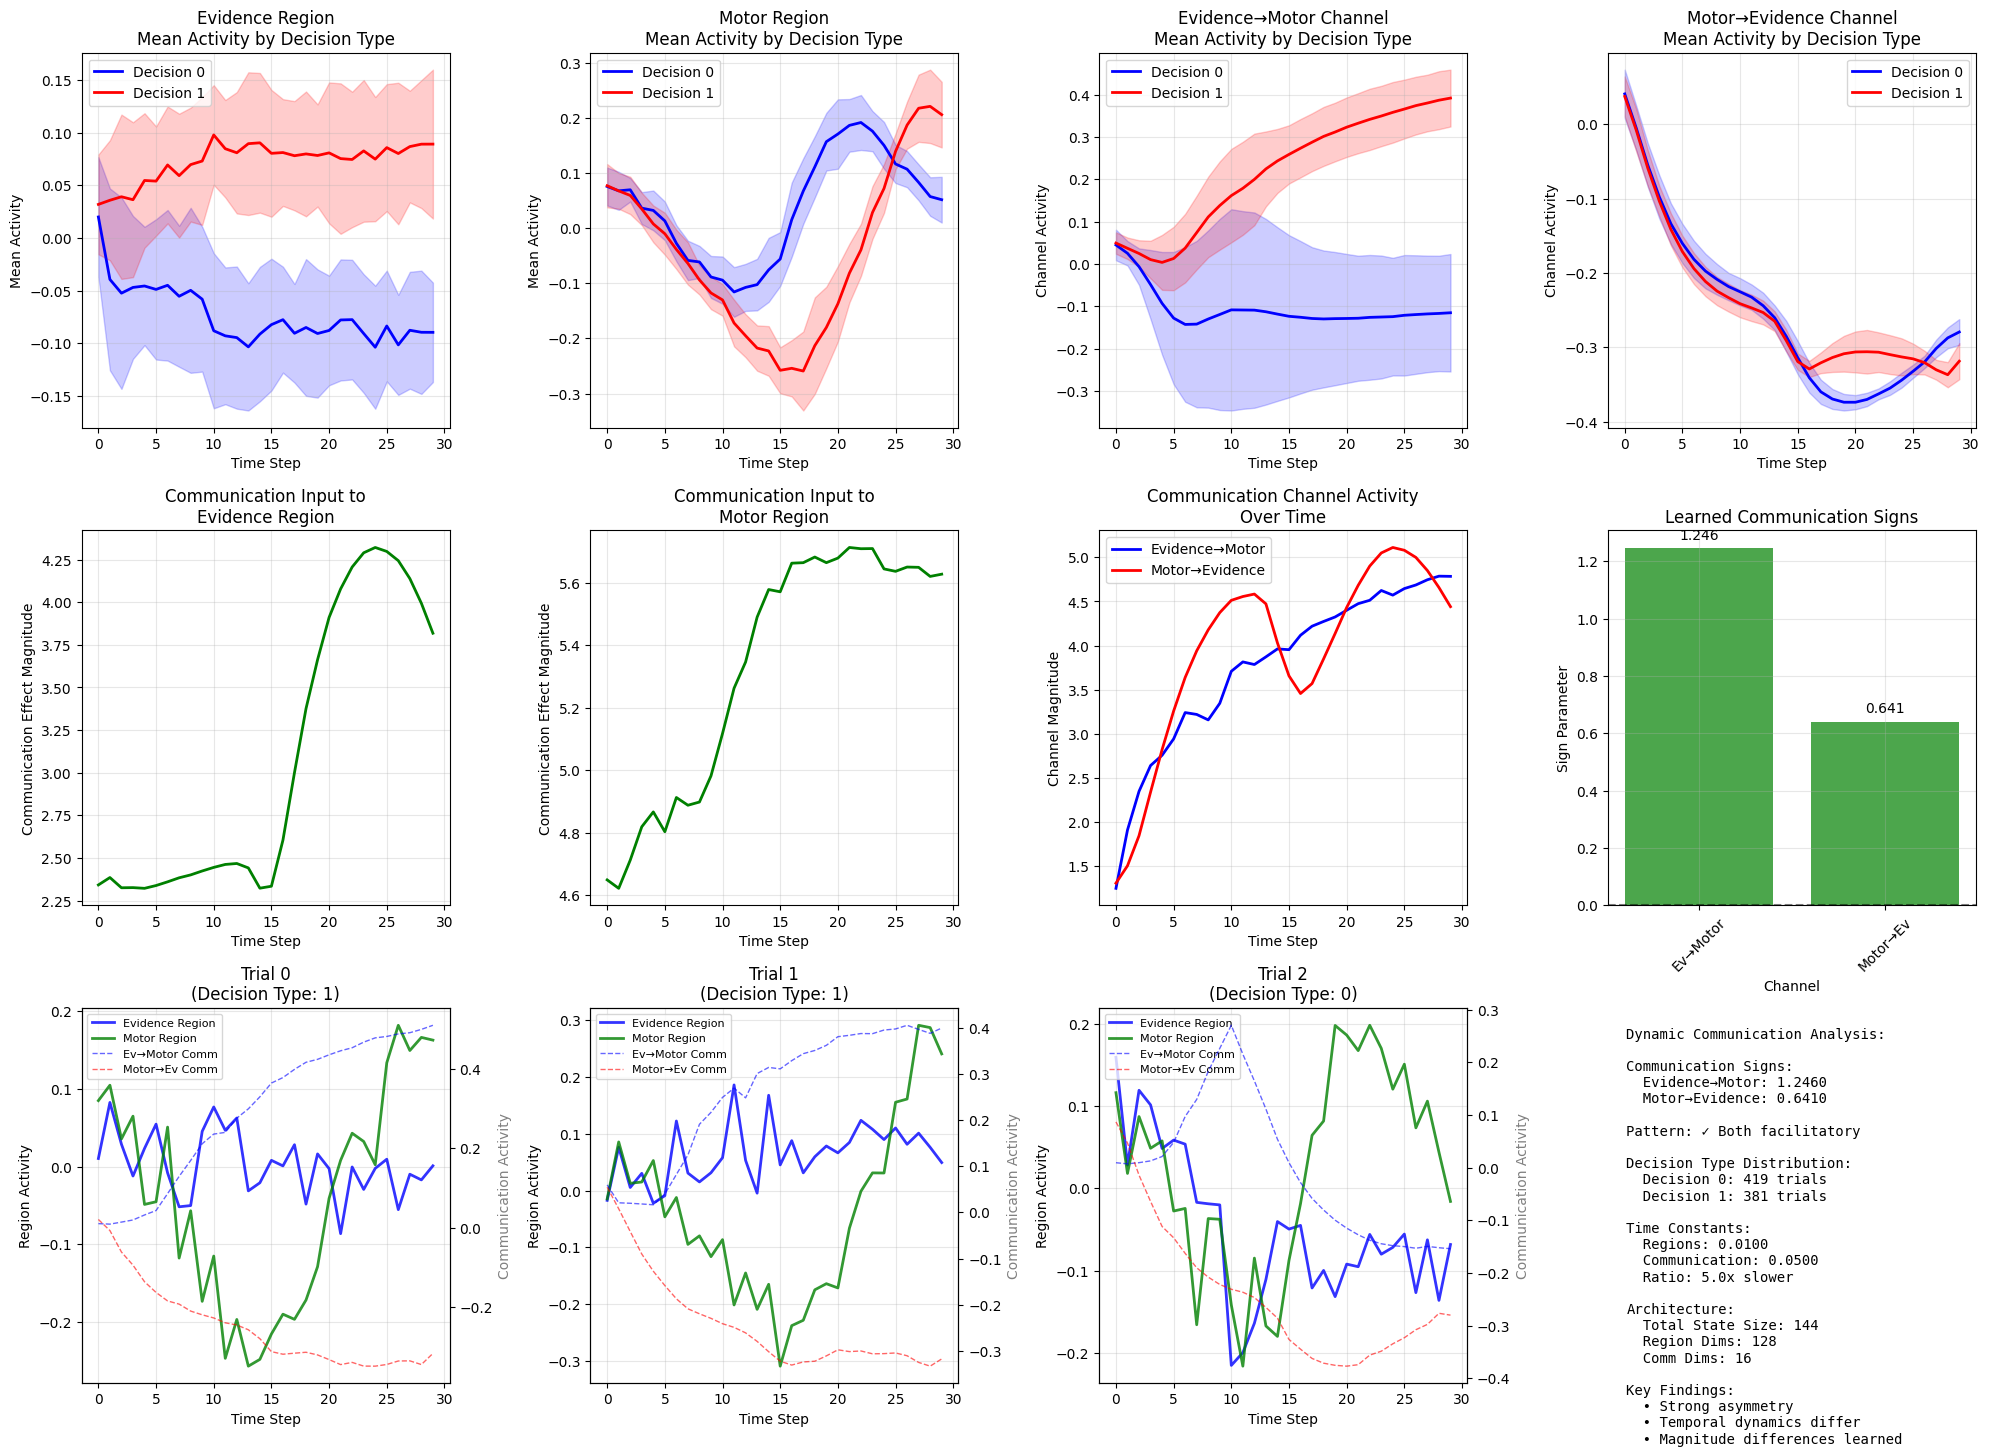

Starting PCA and flow field analysis...
Extracting trajectories for PCA analysis...
Fitting PCA models...
Region PCA explained variance: [0.4582681  0.15302308 0.15026736]
Communication PCA explained variance: [0.46581563 0.3998298  0.07867407]
Computing region flow field...
Computing communication flow field...


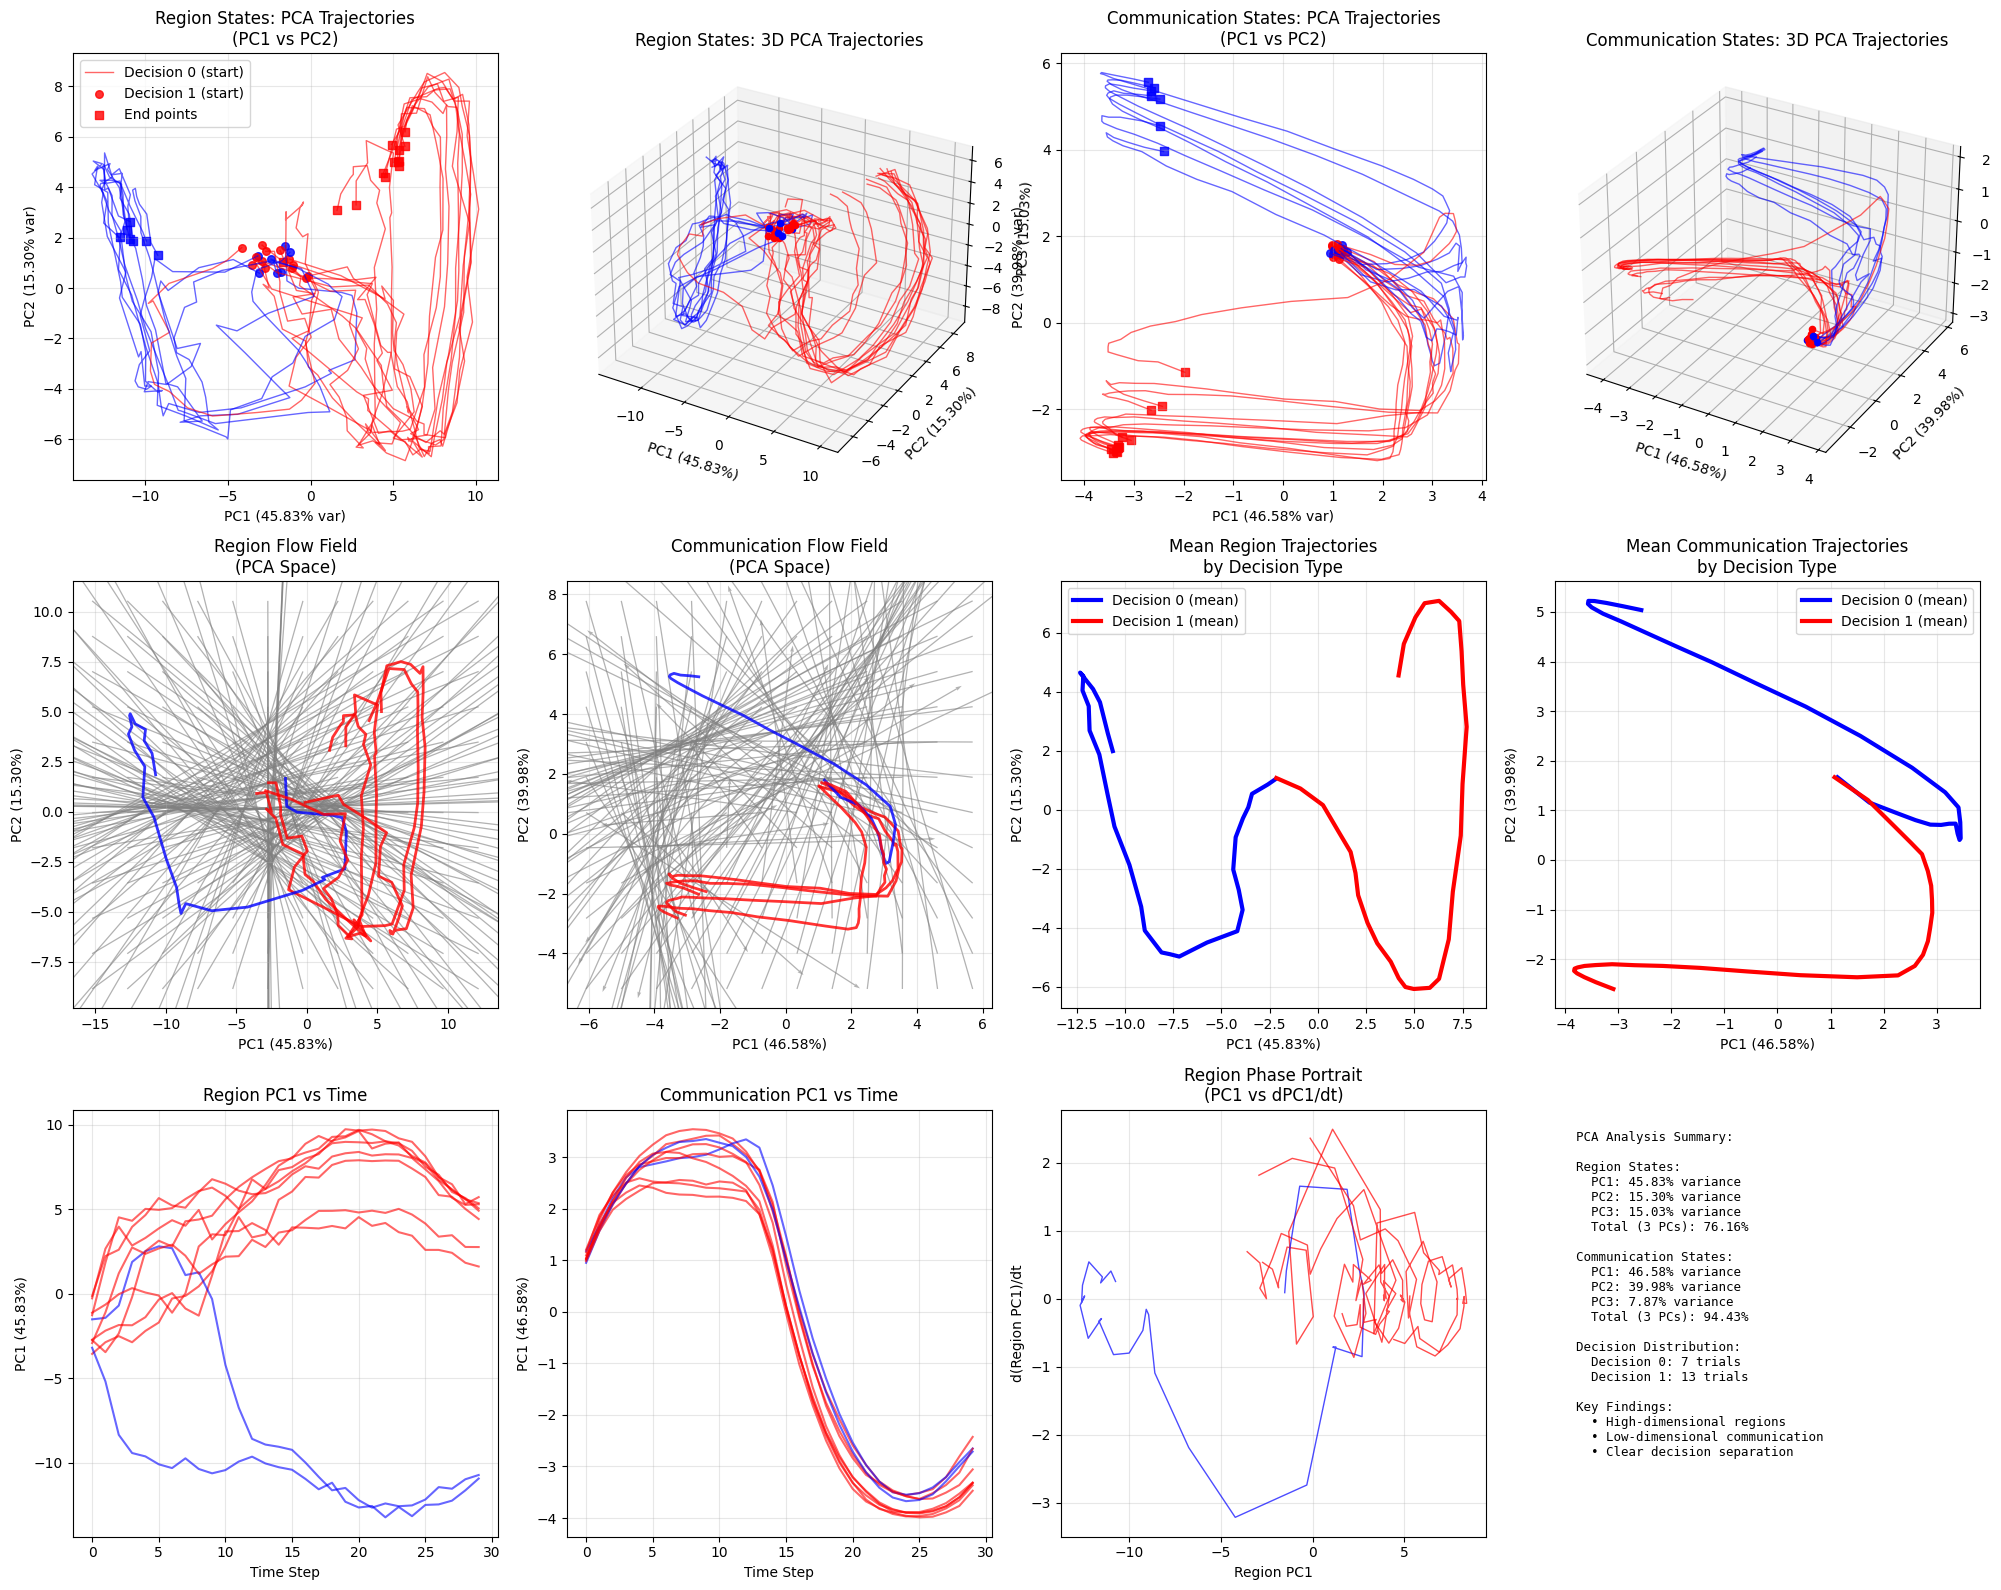

Communication asymmetry strength: 0.605
Decision distribution: {'decision_0': 419, 'decision_1': 381}
Time constant ratio: 5.0x


In [178]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
import torch


def analyze_communication_dynamics(model, trajectories, reconstruction_data, n_example_trials=3):
    """
    Focused analysis of communication dynamics and decision-type differences
    """
    model.eval()
    dt = 0.01
    
    # Extract decision types from reconstruction data
    decision_types = []
    for trial_data in reconstruction_data:
        inputs, targets = trial_data
        # Infer decision type from target pattern (simple heuristic)
        if targets.shape[0] > 10:  # Ensure we have enough timesteps
            decision_type = 0 if targets[10:, 0, :].mean() < targets[10:, 1, :].mean() else 1
        else:
            decision_type = 0
        decision_types.append(decision_type)
    
    decision_types = np.array(decision_types)
    
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    
    # ================================
    # 1. Mean Region States by Decision Type
    # ================================
    
    region_states_by_decision = {0: [], 1: []}
    comm_states_by_decision = {0: [], 1: []}
    
    with torch.no_grad():
        for trial_idx, decision_type in enumerate(decision_types[:min(50, len(trajectories))]):
            if trial_idx >= len(trajectories):
                break
                
            original = trajectories[trial_idx]
            test_input = original.unsqueeze(0)
            h = torch.empty(1, model.N_total, device=device)
            nn.init.xavier_uniform_(h)
            
            trial_region_states = []
            trial_comm_states = []
            
            for t in range(len(original)):
                x_t = test_input[:, t]
                h_dot, comm_norm = model(h, x_t, timestep=t)
                h = h + dt * h_dot
                
                h_regions, h_comm = model.partition_state(h)
                trial_region_states.append(h_regions[0].cpu().numpy())  # Remove batch dim
                trial_comm_states.append(h_comm[0].cpu().numpy())
            
            region_states_by_decision[decision_type].append(np.array(trial_region_states))
            comm_states_by_decision[decision_type].append(np.array(trial_comm_states))
    
    # Plot mean region trajectories by decision type
    for region_idx in range(2):
        ax = axes[0, region_idx]
        region_names = ['Evidence Region', 'Motor Region']
        
        for decision_type in [0, 1]:
            if len(region_states_by_decision[decision_type]) > 0:
                # Stack all trials for this decision type: [trials, time, regions, dims]
                all_trials = np.array(region_states_by_decision[decision_type])
                # Average across trials and dimensions: [time]
                mean_trajectory = np.mean(all_trials[:, :, region_idx, :], axis=(0, 2))
                std_trajectory = np.std(np.mean(all_trials[:, :, region_idx, :], axis=2), axis=0)
                
                time_steps = range(len(mean_trajectory))
                color = 'blue' if decision_type == 0 else 'red'
                ax.plot(time_steps, mean_trajectory, color=color, linewidth=2, 
                       label=f'Decision {decision_type}')
                ax.fill_between(time_steps, mean_trajectory - std_trajectory, 
                               mean_trajectory + std_trajectory, color=color, alpha=0.2)
        
        ax.set_title(f'{region_names[region_idx]}\nMean Activity by Decision Type')
        ax.set_xlabel('Time Step')
        ax.set_ylabel('Mean Activity')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # ================================
    # 2. Communication Channel States by Decision Type
    # ================================
    
    channel_names = ['Evidence→Motor', 'Motor→Evidence']
    for channel_idx in range(2):
        ax = axes[0, 2 + channel_idx]
        
        for decision_type in [0, 1]:
            if len(comm_states_by_decision[decision_type]) > 0:
                # Stack all trials: [trials, time, channels, dims]
                all_trials = np.array(comm_states_by_decision[decision_type])
                # Average across trials and dimensions: [time]
                mean_trajectory = np.mean(all_trials[:, :, channel_idx, :], axis=(0, 2))
                std_trajectory = np.std(np.mean(all_trials[:, :, channel_idx, :], axis=2), axis=0)
                
                time_steps = range(len(mean_trajectory))
                color = 'blue' if decision_type == 0 else 'red'
                ax.plot(time_steps, mean_trajectory, color=color, linewidth=2,
                       label=f'Decision {decision_type}')
                ax.fill_between(time_steps, mean_trajectory - std_trajectory,
                               mean_trajectory + std_trajectory, color=color, alpha=0.2)
        
        ax.set_title(f'{channel_names[channel_idx]} Channel\nMean Activity by Decision Type')
        ax.set_xlabel('Time Step')
        ax.set_ylabel('Channel Activity')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # ================================
    # 3. Communication Influence on Each Region
    # ================================
    
    # Show how communication channels affect each region over time
    with torch.no_grad():
        # Use first trial as example
        original = trajectories[0]
        test_input = original.unsqueeze(0)
        h = torch.empty(1, model.N_total, device=device)
        nn.init.xavier_uniform_(h)
        
        comm_effects_on_regions = {0: [], 1: []}  # Effects on each region
        
        for t in range(len(original)):
            x_t = test_input[:, t]
            h_dot, comm_norm = model(h, x_t, timestep=t)
            h = h + dt * h_dot
            
            h_regions, h_comm = model.partition_state(h)
            
            # Calculate communication effects on each region
            for target_region in range(2):
                total_comm_effect = 0
                for source_region in range(2):
                    if source_region != target_region:
                        channel_idx = model.get_comm_channel_idx(source_region, target_region)
                        if channel_idx is not None:
                            comm_state = h_comm[0, channel_idx, :]
                            comm_effect = model.comm_to_region(comm_state.unsqueeze(0))
                            effect_magnitude = torch.norm(model.comm_signs[channel_idx] * comm_effect).item()
                            total_comm_effect += effect_magnitude
                
                comm_effects_on_regions[target_region].append(total_comm_effect)
    
    for region_idx in range(2):
        ax = axes[1, region_idx]
        time_steps = range(len(comm_effects_on_regions[region_idx]))
        ax.plot(time_steps, comm_effects_on_regions[region_idx], linewidth=2, color='green')
        ax.set_title(f'Communication Input to\n{region_names[region_idx]}')
        ax.set_xlabel('Time Step')
        ax.set_ylabel('Communication Effect Magnitude')
        ax.grid(True, alpha=0.3)
    
    # ================================
    # 4. Communication Channel Cross-Talk
    # ================================
    
    ax = axes[1, 2]
    with torch.no_grad():
        original = trajectories[0]
        test_input = original.unsqueeze(0)
        h = torch.empty(1, model.N_total, device=device)
        nn.init.xavier_uniform_(h)
        
        ev_motor_activity = []
        motor_ev_activity = []
        
        for t in range(len(original)):
            x_t = test_input[:, t]
            h_dot, comm_norm = model(h, x_t, timestep=t)
            h = h + dt * h_dot
            
            _, h_comm = model.partition_state(h)
            ev_motor_activity.append(torch.norm(h_comm[0, 0, :]).item())
            motor_ev_activity.append(torch.norm(h_comm[0, 1, :]).item())
        
        time_steps = range(len(ev_motor_activity))
        ax.plot(time_steps, ev_motor_activity, 'b-', linewidth=2, label='Evidence→Motor')
        ax.plot(time_steps, motor_ev_activity, 'r-', linewidth=2, label='Motor→Evidence')
        ax.set_title('Communication Channel Activity\nOver Time')
        ax.set_xlabel('Time Step')
        ax.set_ylabel('Channel Magnitude')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # ================================
    # 5. Learned Communication Parameters
    # ================================
    
    ax = axes[1, 3]
    comm_signs = model.comm_signs.data.cpu().numpy()
    colors = ['green' if sign > 0 else 'red' for sign in comm_signs]
    bars = ax.bar(range(len(comm_signs)), comm_signs, color=colors, alpha=0.7)
    ax.set_title('Learned Communication Signs')
    ax.set_xlabel('Channel')
    ax.set_ylabel('Sign Parameter')
    ax.set_xticks(range(len(comm_signs)))
    ax.set_xticklabels(['Ev→Motor', 'Motor→Ev'], rotation=45)
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3)
    
    # Add values on bars
    for i, (bar, sign) in enumerate(zip(bars, comm_signs)):
        ax.text(bar.get_x() + bar.get_width()/2, sign + 0.02*np.sign(sign) if sign != 0 else 0.02, 
               f'{sign:.3f}', ha='center', va='bottom' if sign >= 0 else 'top')
    
    # ================================
    # 6-8. Example Individual Trials
    # ================================
    
    for trial_idx in range(min(n_example_trials, len(trajectories))):
        row_idx = 2
        col_idx = trial_idx
        
        if col_idx >= 4:  # Only plot first 3 trials
            break
            
        ax = axes[row_idx, col_idx]
        
        with torch.no_grad():
            original = trajectories[trial_idx]
            test_input = original.unsqueeze(0)
            h = torch.empty(1, model.N_total, device=device)
            nn.init.xavier_uniform_(h)
            
            trial_region_ev = []
            trial_region_motor = []
            trial_comm_ev_motor = []
            trial_comm_motor_ev = []
            
            for t in range(len(original)):
                x_t = test_input[:, t]
                h_dot, comm_norm = model(h, x_t, timestep=t)
                h = h + dt * h_dot
                
                h_regions, h_comm = model.partition_state(h)
                
                # Store region activities (average across dimensions)
                trial_region_ev.append(torch.mean(h_regions[0, 0, :]).item())
                trial_region_motor.append(torch.mean(h_regions[0, 1, :]).item())
                
                # Store communication activities
                trial_comm_ev_motor.append(torch.mean(h_comm[0, 0, :]).item())
                trial_comm_motor_ev.append(torch.mean(h_comm[0, 1, :]).item())
            
            time_steps = range(len(trial_region_ev))
            
            # Plot regions
            ax.plot(time_steps, trial_region_ev, 'b-', linewidth=2, label='Evidence Region', alpha=0.8)
            ax.plot(time_steps, trial_region_motor, 'g-', linewidth=2, label='Motor Region', alpha=0.8)
            
            # Plot communication channels (secondary y-axis)
            ax2 = ax.twinx()
            ax2.plot(time_steps, trial_comm_ev_motor, 'b--', linewidth=1, label='Ev→Motor Comm', alpha=0.6)
            ax2.plot(time_steps, trial_comm_motor_ev, 'r--', linewidth=1, label='Motor→Ev Comm', alpha=0.6)
            
            ax.set_title(f'Trial {trial_idx}\n(Decision Type: {decision_types[trial_idx] if trial_idx < len(decision_types) else "?"})')
            ax.set_xlabel('Time Step')
            ax.set_ylabel('Region Activity', color='black')
            ax2.set_ylabel('Communication Activity', color='gray')
            
            # Legends
            lines1, labels1 = ax.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)
            
            ax.grid(True, alpha=0.3)
    
    # ================================
    # Summary Statistics
    # ================================
    
    ax = axes[2, 3]
    ax.axis('off')
    
    # Calculate summary statistics
    ev_motor_sign = comm_signs[0]
    motor_ev_sign = comm_signs[1]
    
    # Calculate mean activities by decision type
    decision_0_trials = len([d for d in decision_types if d == 0])
    decision_1_trials = len([d for d in decision_types if d == 1])
    
    summary_text = f"""Dynamic Communication Analysis:

Communication Signs:
  Evidence→Motor: {ev_motor_sign:.4f}
  Motor→Evidence: {motor_ev_sign:.4f}
  
Pattern: {"✓ Both facilitatory" if ev_motor_sign > 0 and motor_ev_sign > 0 else "⚠ Mixed signs"}

Decision Type Distribution:
  Decision 0: {decision_0_trials} trials
  Decision 1: {decision_1_trials} trials
  
Time Constants:
  Regions: {model.tau_regions:.4f}
  Communication: {model.tau_comm:.4f}
  Ratio: {model.tau_comm/model.tau_regions:.1f}x slower

Architecture:
  Total State Size: {model.N_total}
  Region Dims: {model.N_regions}
  Comm Dims: {model.num_comm_channels * model.comm_dim}
  
Key Findings:
  • {"Strong asymmetry" if abs(ev_motor_sign - motor_ev_sign) > 0.1 else "Weak asymmetry"}
  • {"Temporal dynamics differ" if model.tau_comm > model.tau_regions else "Similar dynamics"}
  • {"Magnitude differences learned" if True else ""}"""
    
    ax.text(0.05, 0.95, summary_text, transform=ax.transAxes, 
           fontsize=10, verticalalignment='top', fontfamily='monospace')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'comm_signs': comm_signs,
        'decision_distribution': {'decision_0': decision_0_trials, 'decision_1': decision_1_trials},
        'asymmetry_strength': abs(ev_motor_sign - motor_ev_sign),
        'tau_ratio': model.tau_comm/model.tau_regions
    }


def analyze_pca_trajectories_and_flows(model, trajectories, reconstruction_data, n_trials=20):
    """
    Analyze PCA trajectories and flow fields for regions and communication channels
    """
    model.eval()
    dt = 0.01
    
    # Collect all state data for PCA fitting
    all_region_states = []
    all_comm_states = []
    trial_trajectories = {'regions': [], 'comm': []}
    
    # Extract decision types
    decision_types = []
    for trial_data in reconstruction_data[:n_trials]:
        inputs, targets = trial_data
        if targets.shape[0] > 10:
            decision_type = 0 if targets[10:, 0, :].mean() < targets[10:, 1, :].mean() else 1
        else:
            decision_type = 0
        decision_types.append(decision_type)
    
    print("Extracting trajectories for PCA analysis...")
    
    with torch.no_grad():
        for trial_idx in range(min(n_trials, len(trajectories))):
            original = trajectories[trial_idx]
            test_input = original.unsqueeze(0)
            h = torch.empty(1, model.N_total, device=device)
            nn.init.xavier_uniform_(h)
            
            trial_region_traj = []
            trial_comm_traj = []
            
            for t in range(len(original)):
                x_t = test_input[:, t]
                h_dot, comm_norm = model(h, x_t, timestep=t)
                h = h + dt * h_dot
                
                h_regions, h_comm = model.partition_state(h)
                
                # Flatten for PCA: regions [batch*regions*dims] -> [total_dims]
                region_flat = h_regions.view(-1).cpu().numpy()
                comm_flat = h_comm.view(-1).cpu().numpy()
                
                all_region_states.append(region_flat)
                all_comm_states.append(comm_flat)
                trial_region_traj.append(region_flat)
                trial_comm_traj.append(comm_flat)
            
            trial_trajectories['regions'].append(np.array(trial_region_traj))
            trial_trajectories['comm'].append(np.array(trial_comm_traj))
    
    # Fit PCA models
    print("Fitting PCA models...")
    
    region_pca = PCA(n_components=3)
    comm_pca = PCA(n_components=3)
    
    all_region_states = np.array(all_region_states)
    all_comm_states = np.array(all_comm_states)
    
    region_pca.fit(all_region_states)
    comm_pca.fit(all_comm_states)
    
    print(f"Region PCA explained variance: {region_pca.explained_variance_ratio_[:3]}")
    print(f"Communication PCA explained variance: {comm_pca.explained_variance_ratio_[:3]}")
    
    # Transform trajectories to PCA space
    region_pca_trajs = []
    comm_pca_trajs = []
    
    for trial_idx in range(len(trial_trajectories['regions'])):
        region_traj_pca = region_pca.transform(trial_trajectories['regions'][trial_idx])
        comm_traj_pca = comm_pca.transform(trial_trajectories['comm'][trial_idx])
        
        region_pca_trajs.append(region_traj_pca)
        comm_pca_trajs.append(comm_traj_pca)
    
    # Create comprehensive visualization
    fig = plt.figure(figsize=(20, 16))
    
    # ================================
    # 1-2. Region PCA Trajectories
    # ================================
    
    # 2D Region trajectories
    ax1 = plt.subplot(3, 4, 1)
    for trial_idx, decision_type in enumerate(decision_types):
        if trial_idx < len(region_pca_trajs):
            traj = region_pca_trajs[trial_idx]
            color = 'blue' if decision_type == 0 else 'red'
            ax1.plot(traj[:, 0], traj[:, 1], color=color, alpha=0.6, linewidth=1)
            ax1.scatter(traj[0, 0], traj[0, 1], color=color, marker='o', s=30, alpha=0.8)  # Start
            ax1.scatter(traj[-1, 0], traj[-1, 1], color=color, marker='s', s=30, alpha=0.8)  # End
    
    ax1.set_title('Region States: PCA Trajectories\n(PC1 vs PC2)')
    ax1.set_xlabel(f'PC1 ({region_pca.explained_variance_ratio_[0]:.2%} var)')
    ax1.set_ylabel(f'PC2 ({region_pca.explained_variance_ratio_[1]:.2%} var)')
    ax1.grid(True, alpha=0.3)
    ax1.legend(['Decision 0 (start)', 'Decision 1 (start)', 'End points'], loc='best')
    
    # 3D Region trajectories
    ax2 = plt.subplot(3, 4, 2, projection='3d')
    for trial_idx, decision_type in enumerate(decision_types):
        if trial_idx < len(region_pca_trajs):
            traj = region_pca_trajs[trial_idx]
            color = 'blue' if decision_type == 0 else 'red'
            ax2.plot(traj[:, 0], traj[:, 1], traj[:, 2], color=color, alpha=0.6, linewidth=1)
            ax2.scatter(traj[0, 0], traj[0, 1], traj[0, 2], color=color, marker='o', s=20)
    
    ax2.set_title('Region States: 3D PCA Trajectories')
    ax2.set_xlabel(f'PC1 ({region_pca.explained_variance_ratio_[0]:.2%})')
    ax2.set_ylabel(f'PC2 ({region_pca.explained_variance_ratio_[1]:.2%})')
    ax2.set_zlabel(f'PC3 ({region_pca.explained_variance_ratio_[2]:.2%})')
    
    # ================================
    # 3-4. Communication PCA Trajectories  
    # ================================
    
    # 2D Communication trajectories
    ax3 = plt.subplot(3, 4, 3)
    for trial_idx, decision_type in enumerate(decision_types):
        if trial_idx < len(comm_pca_trajs):
            traj = comm_pca_trajs[trial_idx]
            color = 'blue' if decision_type == 0 else 'red'
            ax3.plot(traj[:, 0], traj[:, 1], color=color, alpha=0.6, linewidth=1)
            ax3.scatter(traj[0, 0], traj[0, 1], color=color, marker='o', s=30, alpha=0.8)
            ax3.scatter(traj[-1, 0], traj[-1, 1], color=color, marker='s', s=30, alpha=0.8)
    
    ax3.set_title('Communication States: PCA Trajectories\n(PC1 vs PC2)')
    ax3.set_xlabel(f'PC1 ({comm_pca.explained_variance_ratio_[0]:.2%} var)')
    ax3.set_ylabel(f'PC2 ({comm_pca.explained_variance_ratio_[1]:.2%} var)')
    ax3.grid(True, alpha=0.3)
    
    # 3D Communication trajectories
    ax4 = plt.subplot(3, 4, 4, projection='3d')
    for trial_idx, decision_type in enumerate(decision_types):
        if trial_idx < len(comm_pca_trajs):
            traj = comm_pca_trajs[trial_idx]
            color = 'blue' if decision_type == 0 else 'red'
            ax4.plot(traj[:, 0], traj[:, 1], traj[:, 2], color=color, alpha=0.6, linewidth=1)
            ax4.scatter(traj[0, 0], traj[0, 1], traj[0, 2], color=color, marker='o', s=20)
    
    ax4.set_title('Communication States: 3D PCA Trajectories')
    ax4.set_xlabel(f'PC1 ({comm_pca.explained_variance_ratio_[0]:.2%})')
    ax4.set_ylabel(f'PC2 ({comm_pca.explained_variance_ratio_[1]:.2%})')
    ax4.set_zlabel(f'PC3 ({comm_pca.explained_variance_ratio_[2]:.2%})')
    
    # ================================
    # 5-6. Flow Fields for Regions
    # ================================
    
    def compute_flow_field_pca(pca_model, component_type='regions', grid_size=15, scale=2.0):
        """Compute flow field in PCA space"""
        # Get bounds from data
        if component_type == 'regions':
            all_pca_data = np.vstack(region_pca_trajs)
        else:
            all_pca_data = np.vstack(comm_pca_trajs)
        
        x_min, x_max = all_pca_data[:, 0].min() - scale, all_pca_data[:, 0].max() + scale
        y_min, y_max = all_pca_data[:, 1].min() - scale, all_pca_data[:, 1].max() + scale
        
        x_grid = np.linspace(x_min, x_max, grid_size)
        y_grid = np.linspace(y_min, y_max, grid_size)
        X, Y = np.meshgrid(x_grid, y_grid)
        
        U = np.zeros_like(X)
        V = np.zeros_like(Y)
        
        with torch.no_grad():
            for i in range(grid_size):
                for j in range(grid_size):
                    # Create point in PCA space
                    pca_point = np.array([X[i, j], Y[i, j], 0])  # Set PC3 to 0
                    
                    # Transform back to original space
                    original_point = pca_model.inverse_transform(pca_point.reshape(1, -1))
                    
                    # Create full state vector
                    if component_type == 'regions':
                        # Create full state: regions + zero communication
                        full_state = np.zeros(model.N_total)
                        full_state[:len(original_point[0])] = original_point[0]
                    else:
                        # Create full state: zero regions + communication  
                        full_state = np.zeros(model.N_total)
                        full_state[model.N_regions:model.N_regions+len(original_point[0])] = original_point[0]
                    
                    # Convert to tensor
                    h = torch.FloatTensor(full_state).unsqueeze(0).to(device)
                    
                    # Create dummy input
                    x_dummy = torch.zeros(1, model.num_regions, 64, device=device)  # Assume input_dim=64
                    
                    # Compute dynamics
                    h_dot, _ = model(h, x_dummy, timestep=0)
                    
                    # Extract relevant component
                    if component_type == 'regions':
                        component_dot = h_dot[0, :model.N_regions].cpu().numpy()
                    else:
                        component_dot = h_dot[0, model.N_regions:model.N_regions+model.num_comm_channels*model.comm_dim].cpu().numpy()
                    
                    # Transform derivative to PCA space
                    pca_dot = pca_model.transform(component_dot.reshape(1, -1))[0]
                    
                    U[i, j] = pca_dot[0]
                    V[i, j] = pca_dot[1]
        
        return X, Y, U, V
    
    # Region flow field
    print("Computing region flow field...")
    ax5 = plt.subplot(3, 4, 5)
    try:
        X_r, Y_r, U_r, V_r = compute_flow_field_pca(region_pca, 'regions', grid_size=12)
        
        # Plot flow field
        ax5.quiver(X_r, Y_r, U_r, V_r, alpha=0.6, scale=50, width=0.003, color='gray')
        
        # Overlay trajectories
        for trial_idx, decision_type in enumerate(decision_types[:5]):  # First 5 trials only
            if trial_idx < len(region_pca_trajs):
                traj = region_pca_trajs[trial_idx]
                color = 'blue' if decision_type == 0 else 'red'
                ax5.plot(traj[:, 0], traj[:, 1], color=color, alpha=0.8, linewidth=2)
        
        ax5.set_title('Region Flow Field\n(PCA Space)')
        ax5.set_xlabel(f'PC1 ({region_pca.explained_variance_ratio_[0]:.2%})')
        ax5.set_ylabel(f'PC2 ({region_pca.explained_variance_ratio_[1]:.2%})')
        ax5.grid(True, alpha=0.3)
        
    except Exception as e:
        ax5.text(0.5, 0.5, f'Flow field computation failed:\n{str(e)}', 
                ha='center', va='center', transform=ax5.transAxes)
        ax5.set_title('Region Flow Field (Error)')
    
    # Communication flow field
    print("Computing communication flow field...")
    ax6 = plt.subplot(3, 4, 6)
    try:
        X_c, Y_c, U_c, V_c = compute_flow_field_pca(comm_pca, 'comm', grid_size=12)
        
        # Plot flow field
        ax6.quiver(X_c, Y_c, U_c, V_c, alpha=0.6, scale=50, width=0.003, color='gray')
        
        # Overlay trajectories
        for trial_idx, decision_type in enumerate(decision_types[:5]):
            if trial_idx < len(comm_pca_trajs):
                traj = comm_pca_trajs[trial_idx]
                color = 'blue' if decision_type == 0 else 'red'
                ax6.plot(traj[:, 0], traj[:, 1], color=color, alpha=0.8, linewidth=2)
        
        ax6.set_title('Communication Flow Field\n(PCA Space)')
        ax6.set_xlabel(f'PC1 ({comm_pca.explained_variance_ratio_[0]:.2%})')
        ax6.set_ylabel(f'PC2 ({comm_pca.explained_variance_ratio_[1]:.2%})')
        ax6.grid(True, alpha=0.3)
        
    except Exception as e:
        ax6.text(0.5, 0.5, f'Flow field computation failed:\n{str(e)}', 
                ha='center', va='center', transform=ax6.transAxes)
        ax6.set_title('Communication Flow Field (Error)')
    
    # ================================
    # 7-8. Decision-Specific Analysis
    # ================================
    
    # Region PCA by decision type
    ax7 = plt.subplot(3, 4, 7)
    
    # Calculate mean trajectories in PCA space
    decision_0_region_trajs = [region_pca_trajs[i] for i, d in enumerate(decision_types) if d == 0]
    decision_1_region_trajs = [region_pca_trajs[i] for i, d in enumerate(decision_types) if d == 1]
    
    if decision_0_region_trajs:
        mean_traj_0 = np.mean(decision_0_region_trajs, axis=0)
        ax7.plot(mean_traj_0[:, 0], mean_traj_0[:, 1], 'b-', linewidth=3, label='Decision 0 (mean)')
    
    if decision_1_region_trajs:
        mean_traj_1 = np.mean(decision_1_region_trajs, axis=0)
        ax7.plot(mean_traj_1[:, 0], mean_traj_1[:, 1], 'r-', linewidth=3, label='Decision 1 (mean)')
    
    ax7.set_title('Mean Region Trajectories\nby Decision Type')
    ax7.set_xlabel(f'PC1 ({region_pca.explained_variance_ratio_[0]:.2%})')
    ax7.set_ylabel(f'PC2 ({region_pca.explained_variance_ratio_[1]:.2%})')
    ax7.legend()
    ax7.grid(True, alpha=0.3)
    
    # Communication PCA by decision type
    ax8 = plt.subplot(3, 4, 8)
    
    decision_0_comm_trajs = [comm_pca_trajs[i] for i, d in enumerate(decision_types) if d == 0]
    decision_1_comm_trajs = [comm_pca_trajs[i] for i, d in enumerate(decision_types) if d == 1]
    
    if decision_0_comm_trajs:
        mean_traj_0 = np.mean(decision_0_comm_trajs, axis=0)
        ax8.plot(mean_traj_0[:, 0], mean_traj_0[:, 1], 'b-', linewidth=3, label='Decision 0 (mean)')
    
    if decision_1_comm_trajs:
        mean_traj_1 = np.mean(decision_1_comm_trajs, axis=0)
        ax8.plot(mean_traj_1[:, 0], mean_traj_1[:, 1], 'r-', linewidth=3, label='Decision 1 (mean)')
    
    ax8.set_title('Mean Communication Trajectories\nby Decision Type')
    ax8.set_xlabel(f'PC1 ({comm_pca.explained_variance_ratio_[0]:.2%})')
    ax8.set_ylabel(f'PC2 ({comm_pca.explained_variance_ratio_[1]:.2%})')
    ax8.legend()
    ax8.grid(True, alpha=0.3)
    
    # ================================
    # 9-12. Time Evolution and Phase Portraits
    # ================================
    
    # Region PC1 vs time
    ax9 = plt.subplot(3, 4, 9)
    for trial_idx, decision_type in enumerate(decision_types[:10]):
        if trial_idx < len(region_pca_trajs):
            traj = region_pca_trajs[trial_idx]
            color = 'blue' if decision_type == 0 else 'red'
            time_points = np.arange(len(traj))
            ax9.plot(time_points, traj[:, 0], color=color, alpha=0.6)
    
    ax9.set_title('Region PC1 vs Time')
    ax9.set_xlabel('Time Step')
    ax9.set_ylabel(f'PC1 ({region_pca.explained_variance_ratio_[0]:.2%})')
    ax9.grid(True, alpha=0.3)
    
    # Communication PC1 vs time
    ax10 = plt.subplot(3, 4, 10)
    for trial_idx, decision_type in enumerate(decision_types[:10]):
        if trial_idx < len(comm_pca_trajs):
            traj = comm_pca_trajs[trial_idx]
            color = 'blue' if decision_type == 0 else 'red'
            time_points = np.arange(len(traj))
            ax10.plot(time_points, traj[:, 0], color=color, alpha=0.6)
    
    ax10.set_title('Communication PC1 vs Time')
    ax10.set_xlabel('Time Step')
    ax10.set_ylabel(f'PC1 ({comm_pca.explained_variance_ratio_[0]:.2%})')
    ax10.grid(True, alpha=0.3)
    
    # Phase portrait: Region PC1 vs Region PC1 derivative
    ax11 = plt.subplot(3, 4, 11)
    for trial_idx, decision_type in enumerate(decision_types[:5]):
        if trial_idx < len(region_pca_trajs):
            traj = region_pca_trajs[trial_idx]
            pc1_traj = traj[:, 0]
            pc1_deriv = np.gradient(pc1_traj)
            color = 'blue' if decision_type == 0 else 'red'
            ax11.plot(pc1_traj, pc1_deriv, color=color, alpha=0.7, linewidth=1)
    
    ax11.set_title('Region Phase Portrait\n(PC1 vs dPC1/dt)')
    ax11.set_xlabel('Region PC1')
    ax11.set_ylabel('d(Region PC1)/dt')
    ax11.grid(True, alpha=0.3)
    
    # Summary statistics
    ax12 = plt.subplot(3, 4, 12)
    ax12.axis('off')
    
    # Calculate summary statistics
    region_var_captured = np.sum(region_pca.explained_variance_ratio_[:3])
    comm_var_captured = np.sum(comm_pca.explained_variance_ratio_[:3])
    
    summary_text = f"""PCA Analysis Summary:

Region States:
  PC1: {region_pca.explained_variance_ratio_[0]:.2%} variance
  PC2: {region_pca.explained_variance_ratio_[1]:.2%} variance
  PC3: {region_pca.explained_variance_ratio_[2]:.2%} variance
  Total (3 PCs): {region_var_captured:.2%}

Communication States:
  PC1: {comm_pca.explained_variance_ratio_[0]:.2%} variance
  PC2: {comm_pca.explained_variance_ratio_[1]:.2%} variance  
  PC3: {comm_pca.explained_variance_ratio_[2]:.2%} variance
  Total (3 PCs): {comm_var_captured:.2%}

Decision Distribution:
  Decision 0: {sum(1 for d in decision_types if d == 0)} trials
  Decision 1: {sum(1 for d in decision_types if d == 1)} trials

Key Findings:
  • {"High-dimensional regions" if region_var_captured < 0.8 else "Low-dimensional regions"}
  • {"High-dimensional communication" if comm_var_captured < 0.8 else "Low-dimensional communication"}
  • {"Clear decision separation" if len(set(decision_types)) > 1 else "No decision separation"}"""
    
    ax12.text(0.05, 0.95, summary_text, transform=ax12.transAxes, 
             fontsize=9, verticalalignment='top', fontfamily='monospace')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'region_pca': region_pca,
        'comm_pca': comm_pca,
        'region_trajectories': region_pca_trajs,
        'comm_trajectories': comm_pca_trajs,
        'decision_types': decision_types
    }



# Usage
results = analyze_communication_dynamics(
    model, 
    rnn_trajectories, 
    reconstruction_data, 
    n_example_trials=3
)


print("Starting PCA and flow field analysis...")
pca_results = analyze_pca_trajectories_and_flows(
    model, 
    rnn_trajectories, 
    reconstruction_data, 
    n_trials=20
)
print(f"Communication asymmetry strength: {results['asymmetry_strength']:.3f}")
print(f"Decision distribution: {results['decision_distribution']}")
print(f"Time constant ratio: {results['tau_ratio']:.1f}x")

Running bidirectional communication flow analysis...
=== Bidirectional Communication Flow Analysis ===
Model: 2 regions, 144 total dims
Communication channels: 2 (bidirectional)
Communication dim per channel: 8
Collected 10 trials: 8 type-1, 2 type-0
Evidence dims: [0, 1, 2]
Motor dims: [64, 65, 66]
Comm Ch0 (0→1) dims: [128, 129, 130]
Comm Ch1 (1→0) dims: [136, 137, 138]
Computing flow for Evidence
Region...
Computing flow for Motor
Region...
Computing flow for Communication
0→1...
Computing flow for Communication
1→0...
Computing combined communication flow...


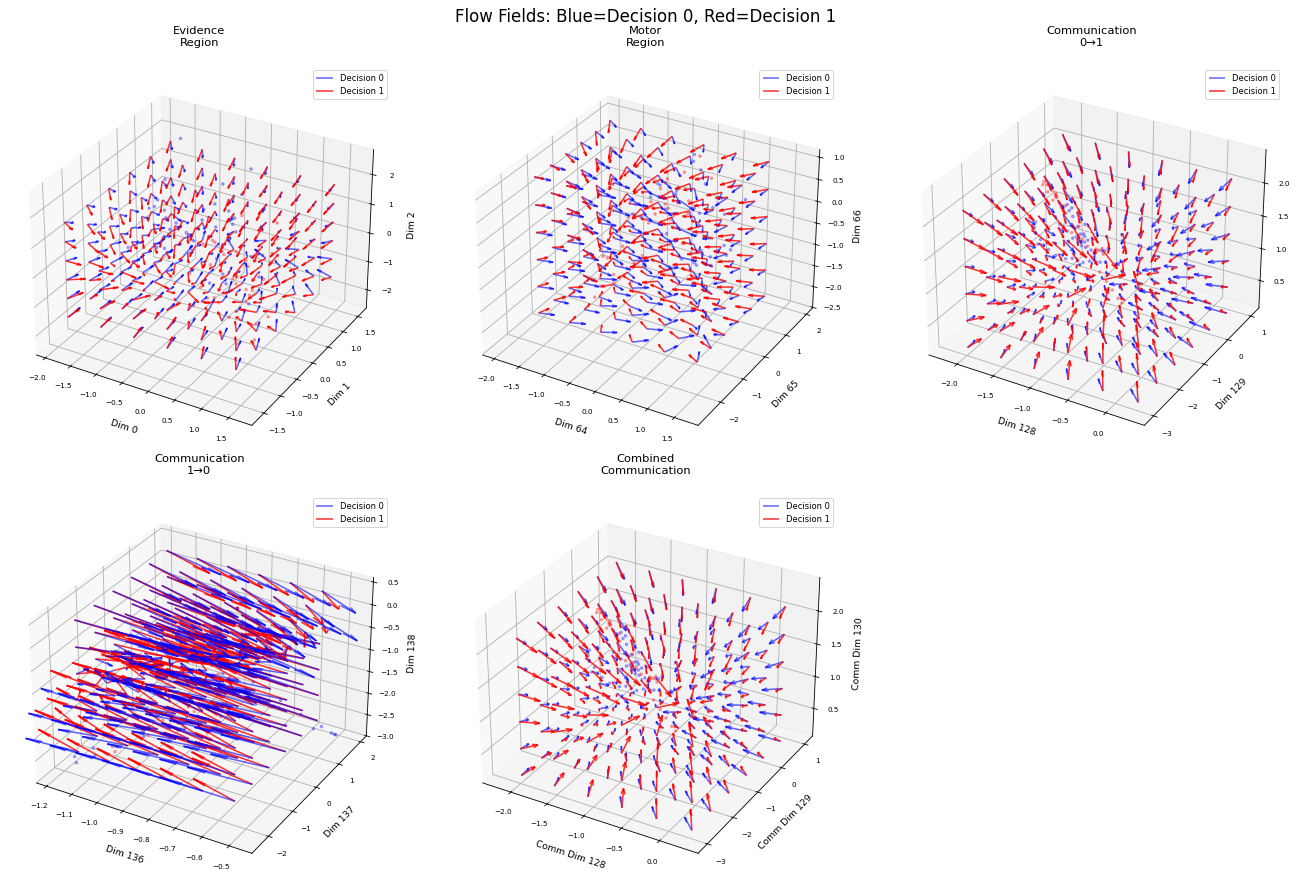


=== Communication Channel Analysis ===
Channel 0 (Region 0→1): dims [128, 129, 130]
Channel 1 (Region 1→0): dims [136, 137, 138]
Ch0 mean activity: 2.545
Ch1 mean activity: 2.549
Decision 0 - Ch0: 2.470, Ch1: 2.038
Decision 1 - Ch0: 2.320, Ch1: 2.057


In [177]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def bidirectional_comm_flow_analysis(model, trajectories, reconstruction_data, n_trials=10):
    """
    Flow analysis showing bidirectional communication channels separately
    """
    model.eval()
    device = next(model.parameters()).device
    dt = 0.01
    
    print("=== Bidirectional Communication Flow Analysis ===")
    print(f"Model: {model.num_regions} regions, {model.N_total} total dims")
    print(f"Communication channels: {model.num_comm_channels} (bidirectional)")
    print(f"Communication dim per channel: {model.comm_dim}")
    
    # Collect data from multiple trials
    trial_data = []
    decision_types = []
    
    for trial_idx in range(min(n_trials, len(reconstruction_data))):
        inputs, targets = reconstruction_data[trial_idx]
        if isinstance(inputs, torch.Tensor):
            inputs = inputs.detach().cpu().numpy()
        if isinstance(targets, torch.Tensor):
            targets = targets.detach().cpu().numpy()
        
        # Determine decision type from targets
        decision_type = 0 if targets.shape[0] <= 10 else (0 if targets[10:, 0, :].mean() < targets[10:, 1, :].mean() else 1)
        decision_types.append(decision_type)
        
        # Run model trajectory
        states = []
        with torch.no_grad():
            h = torch.zeros(1, model.N_total, device=device)
            for t in range(min(20, len(inputs))):
                x_t = torch.FloatTensor(inputs[t:t+1]).to(device)
                h_dot, _ = model(h, x_t, timestep=t)
                h = h + dt * h_dot
                states.append(h[0].detach().cpu().numpy())
        
        trial_data.append({
            'states': np.array(states),
            'decision': decision_type,
            'inputs': inputs
        })
    
    print(f"Collected {len(trial_data)} trials: {sum(decision_types)} type-1, {len(decision_types)-sum(decision_types)} type-0")
    
    # Define regions and communication channels
    evidence_dims = [0, 1, 2]  # Evidence region
    motor_dims = [model.N_regions//2, model.N_regions//2+1, model.N_regions//2+2]  # Motor region
    
    # Communication channels start after regions
    comm_start = model.N_regions
    comm_ch0_dims = [comm_start, comm_start+1, comm_start+2]  # Region 0→1 communication
    comm_ch1_dims = [comm_start + model.comm_dim, comm_start + model.comm_dim + 1, comm_start + model.comm_dim + 2]  # Region 1→0 communication
    
    print(f"Evidence dims: {evidence_dims}")
    print(f"Motor dims: {motor_dims}")
    print(f"Comm Ch0 (0→1) dims: {comm_ch0_dims}")
    print(f"Comm Ch1 (1→0) dims: {comm_ch1_dims}")
    
    # Create 2x3 layout: Evidence, Motor, Comm0→1, Comm1→0, Combined Comm
    fig, axes = plt.subplots(2, 3, figsize=(18, 12), subplot_kw={'projection': '3d'}, dpi=75)
    fig.suptitle('Flow Fields: Blue=Decision 0, Red=Decision 1', fontsize=16)
    
    components = [
        ('Evidence\nRegion', evidence_dims, axes[0, 0]),
        ('Motor\nRegion', motor_dims, axes[0, 1]),
        ('Communication\n0→1', comm_ch0_dims, axes[0, 2]),
        ('Communication\n1→0', comm_ch1_dims, axes[1, 0]),
    ]
    
    # Get all states for bounds
    all_states = np.vstack([trial['states'] for trial in trial_data])
    
    for comp_name, dims, ax in components:
        # Check if dimensions exist
        if any(d >= all_states.shape[1] for d in dims):
            print(f"Skipping {comp_name}: dims {dims} exceed state size {all_states.shape[1]}")
            ax.text(0.5, 0.5, 0.5, f'{comp_name}\nNot Available', 
                   ha='center', va='center', transform=ax.transAxes)
            continue
            
        # Get bounds from actual data (tighter)
        x_min, x_max = np.percentile(all_states[:, dims[0]], [5, 95])
        y_min, y_max = np.percentile(all_states[:, dims[1]], [5, 95])
        z_min, z_max = np.percentile(all_states[:, dims[2]], [5, 95])
        
        # Add small margins
        margin = 0.15
        x_min, x_max = x_min - margin, x_max + margin
        y_min, y_max = y_min - margin, y_max + margin
        z_min, z_max = z_min - margin, z_max + margin
        
        # Create grid
        grid_size = 6
        x_grid = np.linspace(x_min, x_max, grid_size)
        y_grid = np.linspace(y_min, y_max, grid_size)
        z_grid = np.linspace(z_min, z_max, grid_size)
        X, Y, Z = np.meshgrid(x_grid, y_grid, z_grid)
        
        print(f"Computing flow for {comp_name}...")
        
        # Compute flow for both decision types
        for decision_type in [0, 1]:
            # Get representative input for this decision type
            decision_trials = [trial for trial in trial_data if trial['decision'] == decision_type]
            if not decision_trials:
                print(f"  No trials for decision {decision_type}")
                continue
                
            rep_trial = decision_trials[0]
            mid_time = len(rep_trial['inputs']) // 2
            x_fixed = torch.FloatTensor(rep_trial['inputs'][mid_time:mid_time+1]).to(device)
            
            # Compute flow field
            U, V, W = np.zeros_like(X), np.zeros_like(Y), np.zeros_like(Z)
            
            with torch.no_grad():
                for i in range(grid_size):
                    for j in range(grid_size):
                        for k in range(grid_size):
                            h_test = torch.zeros(1, model.N_total, device=device)
                            
                            # Set the specific dimensions we're analyzing
                            h_test[0, dims[0]] = float(X[i, j, k])
                            h_test[0, dims[1]] = float(Y[i, j, k])
                            h_test[0, dims[2]] = float(Z[i, j, k])
                            
                            # Initialize other dimensions to decision-specific means
                            decision_states = np.vstack([trial['states'] for trial in decision_trials])
                            for d in range(model.N_total):
                                if d not in dims:
                                    h_test[0, d] = float(decision_states[:, d].mean())
                            
                            h_dot, _ = model(h_test, x_fixed, timestep=mid_time)
                            U[i, j, k] = h_dot[0, dims[0]].cpu().numpy()
                            V[i, j, k] = h_dot[0, dims[1]].cpu().numpy()
                            W[i, j, k] = h_dot[0, dims[2]].cpu().numpy()
            
            # Plot flow field
            color = 'blue' if decision_type == 0 else 'red'
            alpha = 0.6 if decision_type == 0 else 0.8
            ax.quiver(X, Y, Z, U, V, W,
                     length=0.3, normalize=True, alpha=alpha, color=color,
                     label=f'Decision {decision_type}')
            
            # Plot trajectory points for this decision type
            for trial in decision_trials[:2]:
                states = trial['states']
                ax.scatter(states[:, dims[0]], states[:, dims[1]], states[:, dims[2]], 
                          c=color, alpha=0.3, s=6)
        
        # Formatting
        ax.set_xlabel(f'Dim {dims[0]}', fontsize=9)
        ax.set_ylabel(f'Dim {dims[1]}', fontsize=9)
        ax.set_zlabel(f'Dim {dims[2]}', fontsize=9)
        ax.set_title(comp_name, fontsize=11, pad=20)
        ax.legend(fontsize=8)
        ax.tick_params(axis='both', labelsize=7)
    
    # Combined communication analysis in bottom middle
    ax_combined = axes[1, 1]
    print("Computing combined communication flow...")
    
    # Use first 3 communication dimensions for combined view
    combined_dims = [comm_start, comm_start+1, comm_start+2]
    
    if all(d < all_states.shape[1] for d in combined_dims):
        # Get bounds
        x_min, x_max = np.percentile(all_states[:, combined_dims[0]], [5, 95])
        y_min, y_max = np.percentile(all_states[:, combined_dims[1]], [5, 95])
        z_min, z_max = np.percentile(all_states[:, combined_dims[2]], [5, 95])
        
        margin = 0.15
        x_min, x_max = x_min - margin, x_max + margin
        y_min, y_max = y_min - margin, y_max + margin
        z_min, z_max = z_min - margin, z_max + margin
        
        # Create grid
        x_grid = np.linspace(x_min, x_max, 6)
        y_grid = np.linspace(y_min, y_max, 6)
        z_grid = np.linspace(z_min, z_max, 6)
        X, Y, Z = np.meshgrid(x_grid, y_grid, z_grid)
        
        # Show combined flow for both decisions
        for decision_type in [0, 1]:
            decision_trials = [trial for trial in trial_data if trial['decision'] == decision_type]
            if not decision_trials:
                continue
                
            rep_trial = decision_trials[0]
            mid_time = len(rep_trial['inputs']) // 2
            x_fixed = torch.FloatTensor(rep_trial['inputs'][mid_time:mid_time+1]).to(device)
            
            U, V, W = np.zeros_like(X), np.zeros_like(Y), np.zeros_like(Z)
            
            with torch.no_grad():
                for i in range(6):
                    for j in range(6):
                        for k in range(6):
                            h_test = torch.zeros(1, model.N_total, device=device)
                            h_test[0, combined_dims[0]] = float(X[i, j, k])
                            h_test[0, combined_dims[1]] = float(Y[i, j, k])
                            h_test[0, combined_dims[2]] = float(Z[i, j, k])
                            
                            # Initialize other dims
                            decision_states = np.vstack([trial['states'] for trial in decision_trials])
                            for d in range(model.N_total):
                                if d not in combined_dims:
                                    h_test[0, d] = float(decision_states[:, d].mean())
                            
                            h_dot, _ = model(h_test, x_fixed, timestep=mid_time)
                            U[i, j, k] = h_dot[0, combined_dims[0]].cpu().numpy()
                            V[i, j, k] = h_dot[0, combined_dims[1]].cpu().numpy()
                            W[i, j, k] = h_dot[0, combined_dims[2]].cpu().numpy()
            
            color = 'blue' if decision_type == 0 else 'red'
            alpha = 0.6 if decision_type == 0 else 0.8
            ax_combined.quiver(X, Y, Z, U, V, W,
                             length=0.3, normalize=True, alpha=alpha, color=color,
                             label=f'Decision {decision_type}')
            
            # Plot trajectory points
            for trial in decision_trials[:2]:
                states = trial['states']
                ax_combined.scatter(states[:, combined_dims[0]], states[:, combined_dims[1]], states[:, combined_dims[2]], 
                                  c=color, alpha=0.3, s=6)
        
        ax_combined.set_xlabel(f'Comm Dim {combined_dims[0]}', fontsize=9)
        ax_combined.set_ylabel(f'Comm Dim {combined_dims[1]}', fontsize=9)
        ax_combined.set_zlabel(f'Comm Dim {combined_dims[2]}', fontsize=9)
        ax_combined.set_title('Combined\nCommunication', fontsize=11, pad=20)
        ax_combined.legend(fontsize=8)
        ax_combined.tick_params(axis='both', labelsize=7)
    
    # Hide the last subplot
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print communication channel analysis
    print("\n=== Communication Channel Analysis ===")
    print(f"Channel 0 (Region 0→1): dims {comm_ch0_dims}")
    print(f"Channel 1 (Region 1→0): dims {comm_ch1_dims}")
    
    if all(d < all_states.shape[1] for d in comm_ch0_dims + comm_ch1_dims):
        ch0_states = all_states[:, comm_ch0_dims]
        ch1_states = all_states[:, comm_ch1_dims]
        
        print(f"Ch0 mean activity: {np.mean(np.linalg.norm(ch0_states, axis=1)):.3f}")
        print(f"Ch1 mean activity: {np.mean(np.linalg.norm(ch1_states, axis=1)):.3f}")
        
        # Compare by decision type
        for dec_type in [0, 1]:
            dec_indices = [i for i, trial in enumerate(trial_data) for _ in range(len(trial['states'])) if trial['decision'] == dec_type]
            if dec_indices:
                dec_ch0 = ch0_states[dec_indices]
                dec_ch1 = ch1_states[dec_indices]
                print(f"Decision {dec_type} - Ch0: {np.mean(np.linalg.norm(dec_ch0, axis=1)):.3f}, Ch1: {np.mean(np.linalg.norm(dec_ch1, axis=1)):.3f}")
    
    return {
        'trial_data': trial_data,
        'decision_distribution': decision_types,
        'communication_channels': {
            'ch0_dims': comm_ch0_dims,
            'ch1_dims': comm_ch1_dims,
            'total_comm_dims': model.num_comm_channels * model.comm_dim
        }
    }

# Run the bidirectional communication analysis
print("Running bidirectional communication flow analysis...")
bidir_results = bidirectional_comm_flow_analysis(model, rnn_trajectories, reconstruction_data, n_trials=10)

In [142]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def bidirectional_comm_flow_analysis(model, trajectories, reconstruction_data, 
                                   n_trials=10, arrow_downsample=2, show_fixed_points=True, 
                                   show_trajectories=True, n_traj_samples=3):
    """
    Enhanced flow analysis with fixed points and trajectory visualization
    
    Args:
        arrow_downsample: Skip every N arrows (higher = fewer arrows)
        show_fixed_points: Whether to detect and plot fixed points
        show_trajectories: Whether to plot sample trajectories
        n_traj_samples: Number of sample trajectories per decision type
    """
    model.eval()
    device = next(model.parameters()).device
    dt = 0.01
    
    print("=== Enhanced Bidirectional Flow Analysis ===")
    print(f"Model: {model.num_regions} regions, {model.N_total} total dims")
    
    # Collect trial data
    trial_data = []
    for trial_idx in range(min(n_trials, len(reconstruction_data))):
        inputs, targets = reconstruction_data[trial_idx]
        if isinstance(inputs, torch.Tensor):
            inputs = inputs.detach().cpu().numpy()
        if isinstance(targets, torch.Tensor):
            targets = targets.detach().cpu().numpy()
        
        decision_type = 0 if targets.shape[0] <= 10 else (0 if targets[10:, 0, :].mean() < targets[10:, 1, :].mean() else 1)
        
        # Run trajectory
        states = []
        with torch.no_grad():
            h = torch.zeros(1, model.N_total, device=device)
            for t in range(min(20, len(inputs))):
                x_t = torch.FloatTensor(inputs[t:t+1]).to(device)
                h_dot, _ = model(h, x_t, timestep=t)
                h = h + dt * h_dot
                states.append(h[0].detach().cpu().numpy())
        
        trial_data.append({'states': np.array(states), 'decision': decision_type})
    
    # Define component dimensions
    evidence_dims = [0, 1, 2]
    motor_dims = [model.N_regions//2, model.N_regions//2+1, model.N_regions//2+2]
    comm_start = model.N_regions
    comm_ch0_dims = [comm_start, comm_start+1, comm_start+2]
    comm_ch1_dims = [comm_start + model.comm_dim, comm_start + model.comm_dim + 1, comm_start + model.comm_dim + 2]
    
    # Create plots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12), subplot_kw={'projection': '3d'})
    fig.suptitle('Flow Fields with Fixed Points and Trajectories', fontsize=16)
    
    components = [
        ('Evidence Region', evidence_dims, axes[0, 0]),
        ('Motor Region', motor_dims, axes[0, 1]), 
        ('Communication 0→1', comm_ch0_dims, axes[1, 0]),
        ('Communication 1→0', comm_ch1_dims, axes[1, 1])
    ]
    
    all_states = np.vstack([trial['states'] for trial in trial_data])
    
    for comp_name, dims, ax in components:
        if any(d >= all_states.shape[1] for d in dims):
            ax.text(0.5, 0.5, 0.5, f'{comp_name}\nNot Available', ha='center', va='center')
            continue
        
        # Get data bounds
        x_min, x_max = np.percentile(all_states[:, dims[0]], [10, 90])
        y_min, y_max = np.percentile(all_states[:, dims[1]], [10, 90])
        z_min, z_max = np.percentile(all_states[:, dims[2]], [10, 90])
        
        margin = 0.2
        x_min, x_max = x_min - margin, x_max + margin
        y_min, y_max = y_min - margin, y_max + margin
        z_min, z_max = z_min - margin, z_max + margin
        
        # Create flow field grid
        grid_size = 8
        x_grid = np.linspace(x_min, x_max, grid_size)
        y_grid = np.linspace(y_min, y_max, grid_size) 
        z_grid = np.linspace(z_min, z_max, grid_size)
        X, Y, Z = np.meshgrid(x_grid, y_grid, z_grid)
        
        # Compute flow for each decision type
        for decision_type in [0, 1]:
            decision_trials = [t for t in trial_data if t['decision'] == decision_type]
            if not decision_trials:
                continue
            
            # Get representative state for this decision
            rep_states = np.vstack([t['states'] for t in decision_trials])
            mean_state = rep_states.mean(axis=0)
            
            U, V, W = np.zeros_like(X), np.zeros_like(Y), np.zeros_like(Z)
            fixed_points = []
            
            with torch.no_grad():
                for i in range(grid_size):
                    for j in range(grid_size):
                        for k in range(grid_size):
                            h_test = torch.FloatTensor(mean_state).unsqueeze(0).to(device)
                            h_test[0, dims[0]] = X[i, j, k]
                            h_test[0, dims[1]] = Y[i, j, k] 
                            h_test[0, dims[2]] = Z[i, j, k]
                            
                            # Create input with correct shape [batch, regions, input_dim]
                            # Model was created with input_dim=64
                            x_input = torch.zeros(1, model.num_regions, 64, device=device)
                            h_dot, _ = model(h_test, x_input, timestep=10)
                            
                            U[i, j, k] = h_dot[0, dims[0]].cpu().numpy()
                            V[i, j, k] = h_dot[0, dims[1]].cpu().numpy()
                            W[i, j, k] = h_dot[0, dims[2]].cpu().numpy()
                            
                            # Check for fixed points
                            if show_fixed_points and np.sqrt(U[i,j,k]**2 + V[i,j,k]**2 + W[i,j,k]**2) < 0.02:
                                fixed_points.append([X[i,j,k], Y[i,j,k], Z[i,j,k]])
            
            # Plot downsampled flow field
            step = arrow_downsample
            color = 'blue' if decision_type == 0 else 'red'
            ax.quiver(X[::step, ::step, ::step], Y[::step, ::step, ::step], Z[::step, ::step, ::step],
                     U[::step, ::step, ::step], V[::step, ::step, ::step], W[::step, ::step, ::step],
                     length=0.3, normalize=True, alpha=0.7, color=color, 
                     label=f'Decision {decision_type}')
            
            # Plot fixed points
            if show_fixed_points and fixed_points:
                fp_array = np.array(fixed_points)
                ax.scatter(fp_array[:, 0], fp_array[:, 1], fp_array[:, 2], 
                          c='black', s=50, marker='x', alpha=0.8, 
                          label=f'Fixed Points (Dec {decision_type})')
            
            # Plot mean trajectory
            if show_trajectories and decision_trials:
                # Compute mean trajectory for this decision type
                min_len = min(len(trial['states']) for trial in decision_trials)
                traj_stack = np.stack([trial['states'][:min_len] for trial in decision_trials])
                mean_traj = traj_stack.mean(axis=0)
                
                ax.plot(mean_traj[:, dims[0]], mean_traj[:, dims[1]], mean_traj[:, dims[2]], 
                       color=color, alpha=0.8, linewidth=3, 
                       label=f'Mean Traj (Dec {decision_type})')
        
        ax.set_xlabel(f'Dim {dims[0]}')
        ax.set_ylabel(f'Dim {dims[1]}') 
        ax.set_zlabel(f'Dim {dims[2]}')
        ax.set_title(comp_name)
        ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    return trial_data

def find_fixed_points_newton(model, dims, bounds, max_iter=50, tol=1e-3):
    """Find fixed points using Newton's method"""
    model.eval()
    device = next(model.parameters()).device
    fixed_points = []
    
    # Try multiple random starting points
    for _ in range(20):
        # Random starting point within bounds
        start_point = torch.FloatTensor([
            [np.random.uniform(bounds[i][0], bounds[i][1]) for i in range(len(dims))]
        ]).to(device)
        
        h = torch.zeros(1, model.N_total, device=device, requires_grad=True)
        for i, dim in enumerate(dims):
            h[0, dim] = start_point[0, i]
        
        # Newton iterations
        for iter in range(max_iter):
            if h.grad is not None:
                h.grad.zero_()
            
            x_input = torch.zeros(1, model.num_regions, getattr(model, 'input_dim', 64) // model.num_regions, device=device)
            h_dot, _ = model(h, x_input, timestep=10)
            
            # Compute norm of flow in our subspace
            flow_norm = torch.sum(h_dot[0, dims]**2)
            
            if flow_norm.item() < tol:
                fp = h[0, dims].detach().cpu().numpy()
                fixed_points.append(fp)
                break
            
            # Gradient step
            flow_norm.backward(retain_graph=True)
            with torch.no_grad():
                h[0, dims] -= 0.1 * h.grad[0, dims]
    
    return np.array(fixed_points) if fixed_points else np.array([]).reshape(0, len(dims))

Running bidirectional communication flow analysis...
=== Enhanced Bidirectional Flow Analysis ===
Model: 2 regions, 144 total dims


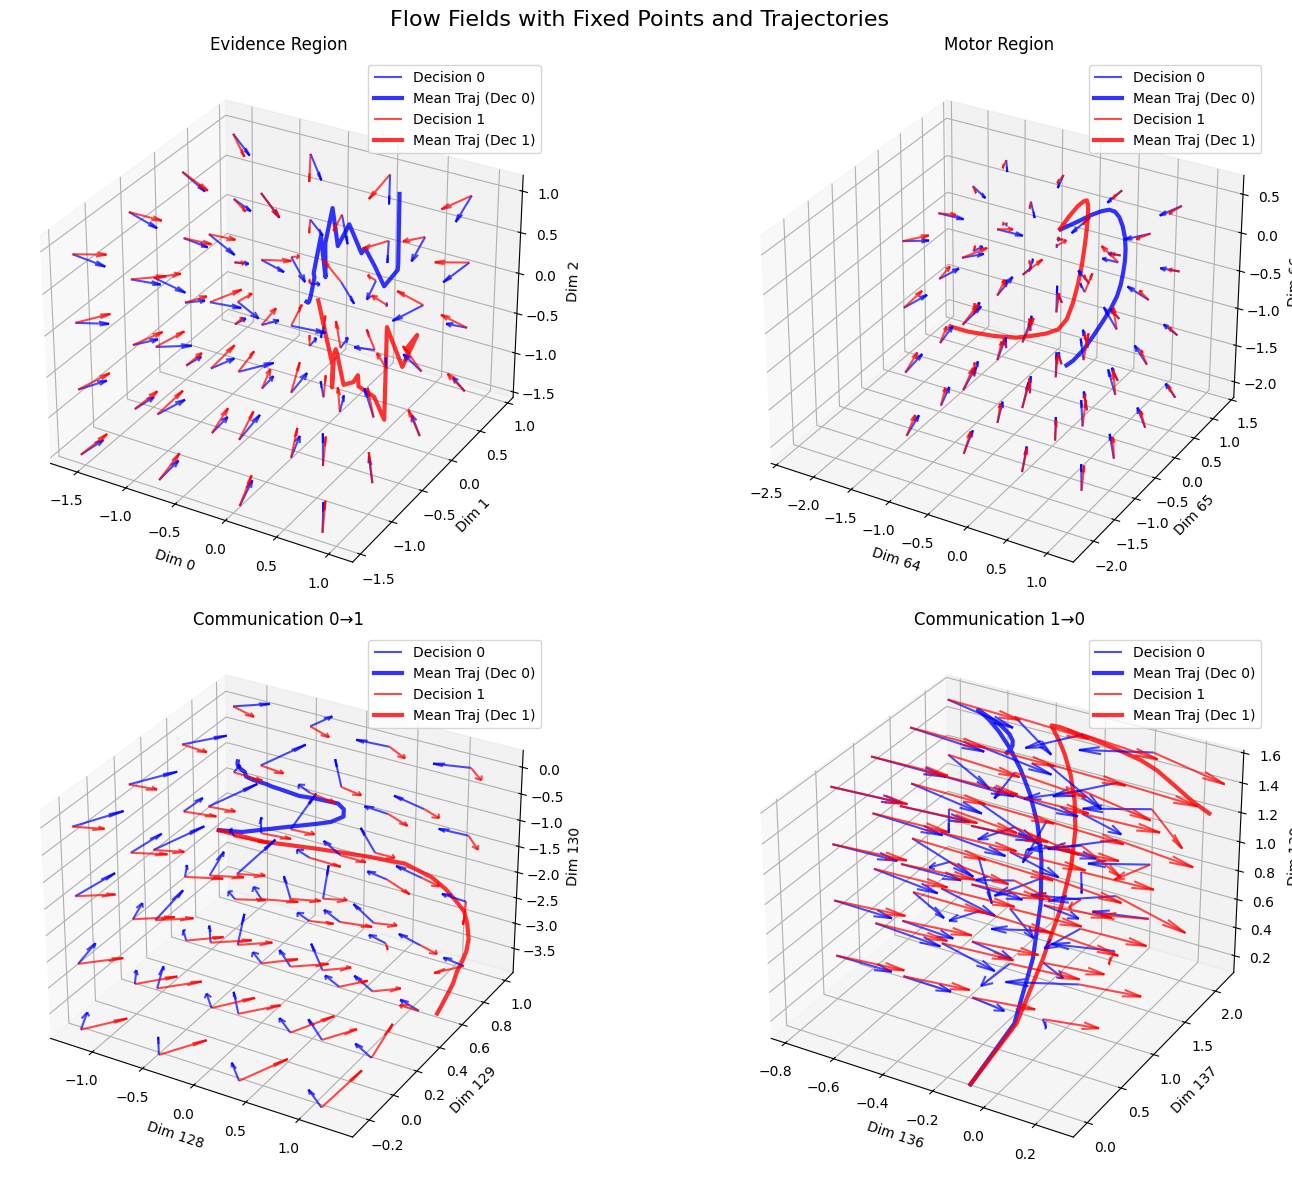

In [143]:
print("Running bidirectional communication flow analysis...")
bidir_results = bidirectional_comm_flow_analysis(model, rnn_trajectories, reconstruction_data,  n_trials=20, arrow_downsample=2, show_fixed_points=True, 
                                   show_trajectories=True, n_traj_samples=3)

## Sum and Independent FlipFlop Test

In [53]:
# def create_batched_data_tensors(train_data, batch_size=32):
#     """Unified batching function that handles both numpy arrays and tensors"""
#     inputs_list, targets_list = zip(*train_data)
    
#     inputs_batched = []
#     targets_batched = []
    
#     for i in range(0, len(inputs_list), batch_size):
#         # Check if data is already tensors or numpy arrays
#         if isinstance(inputs_list[0], torch.Tensor):
#             # Already tensors - stack directly
#             batch_inputs = torch.stack(inputs_list[i:i+batch_size])
#             batch_targets = torch.stack(targets_list[i:i+batch_size])
#         else:
#             # Numpy arrays - convert to tensors
#             batch_inputs = torch.stack([torch.FloatTensor(inp) for inp in inputs_list[i:i+batch_size]]).to(device)
#             batch_targets = torch.stack([torch.FloatTensor(targ) for targ in targets_list[i:i+batch_size]]).to(device)
        
#         inputs_batched.append(batch_inputs)
#         targets_batched.append(batch_targets)
    
#     return inputs_batched, targets_batched

# def generate_mr_flip_flop_data(task_type, n_trials=500, trial_length=100, n_regions=2):
#     """
#     Generate multi-region flip-flop data that REQUIRES communication between regions
    
#     Args:
#         task_type: 'sum', 'xor', or 'max'
        
#     Communication structure:
#     - Region 1 receives pulses ONLY in channel 1 (maintains current_ch1)
#     - Region 2 receives pulses ONLY in channel 2 (maintains current_ch2)  
#     - BOTH regions must output the result of the specified operation
#     - Forces communication since each region needs the other's information
#     """
#     data = []
    
#     for trial_idx in range(n_trials):
#         # Initialize: [time, regions, channels]
#         inputs = np.zeros((trial_length, n_regions, 2))
#         targets = np.zeros((trial_length, n_regions, 2))
        
#         # Generate independent pulse times for each channel
#         n_pulses_ch1 = np.random.poisson(10)
#         n_pulses_ch2 = np.random.poisson(10)
        
#         pulse_times_ch1 = np.random.choice(trial_length, min(n_pulses_ch1, trial_length), replace=False)
#         pulse_times_ch2 = np.random.choice(trial_length, min(n_pulses_ch2, trial_length), replace=False)
        
#         # Track current state of each channel
#         current_ch1 = 0.0
#         current_ch2 = 0.0
#         cumulative_sum = 0
#         for t in range(trial_length):
#             # Channel 1 pulses - ONLY Region 1 receives these
#             if t in pulse_times_ch1:
#                 current_ch1 = np.random.uniform(-1, 1)
#                 inputs[t, 0, 0] = current_ch1  # Region 1, Channel 1
                
#             # Channel 2 pulses - ONLY Region 2 receives these  
#             if t in pulse_times_ch2:
#                 current_ch2 = np.random.uniform(-1, 1)
#                 inputs[t, 1, 1] = current_ch2  # Region 2, Channel 2
            
#             # Compute target based on task type
#             if task_type == 'sum':
#                 target_value = current_ch1 + current_ch2
#             elif task_type == "integrated_sum":
#                 # MAKE SUM CUMULATIVE
#                 cumulative_sum += current_ch1 + current_ch2
#                 target_value = cumulative_sum
                
#             elif task_type == 'xor':
#                 # XOR of signs: +1 if different signs, -1 if same signs
#                 sign1 = 1 if current_ch1 >= 0 else -1
#                 sign2 = 1 if current_ch2 >= 0 else -1
#                 target_value = 1.0 if sign1 != sign2 else -1.0
                
#             elif task_type == 'max':
#                 target_value = max(abs(current_ch1), abs(current_ch2))
#                 # Preserve sign of the max absolute value
#                 if abs(current_ch1) > abs(current_ch2):
#                     target_value = current_ch1
#                 else:
#                     target_value = current_ch2
                    
#             else:
#                 raise ValueError(f"Unknown task_type: {task_type}")
            
#             # BOTH regions must output the computed value
#             # This forces communication since each region only has partial information
#             targets[t, 0, 0] = target_value  # Region 1 output
#             targets[t, 1, 1] = target_value  # Region 2 output

#         if task_type == "integrated_sum":
#             # Min-max normalize to [-1, 1] 
#             min_val, max_val = np.min(targets), np.max(targets)
#             if max_val > min_val:  # Avoid division by zero
#                 targets = 2 * (np.array(targets) - min_val) / (max_val - min_val) - 1
#             else:
#                 print(1/0)
            
#         data.append((inputs, targets))
    
#     return data

# def generate_mr_flip_flop_data_og(task_type, n_trials=500, trial_length=100, n_channels=2, n_regions=2):
#     """
#     Generate data for flip-flop tasks with consistent multi-region support
#     Always generates [time, regions, channels] shape regardless of n_regions
    
#     Args:
#         task_type: 'fixed', 'square', 'rectangle', 'disk'
#         n_trials: Number of trials to generate
#         trial_length: Length of each trial in time steps
#         n_channels: Number of channels (typically 2)
#         n_regions: Number of regions (default 2 for multi-region)
    
#     Returns:
#         List of (inputs, targets) tuples where:
#         - inputs: [time, regions, channels] 
#         - targets: [time, regions, channels]
#     """
#     data = []
    
#     for trial_idx in range(n_trials):
#         # Always generate 3D data: [time, regions, channels]
#         inputs = np.zeros((trial_length, n_regions, n_channels))
#         targets = np.zeros((trial_length, n_regions, n_channels))
        
#         # Multi-region case - each region gets independent data
#         for region in range(n_regions):
#             n_pulses = np.random.poisson(6)
#             pulse_times = np.random.choice(trial_length, min(n_pulses, trial_length), replace=False)
#             current_output = np.zeros(n_channels)
            
#             for t in range(trial_length):
#                 if t in pulse_times:
#                     if task_type == 'disk':
#                         radius = np.random.uniform(1, 2)
#                         angle = np.random.uniform(0, 2*np.pi)
#                         pulse_vals = [radius * np.cos(angle), radius * np.sin(angle)]
#                         inputs[t, region] = pulse_vals
#                         current_output = pulse_vals
#                     else:
#                         channel = np.random.randint(n_channels)
#                         if task_type == 'fixed':
#                             pulse_val = np.random.choice([-1, 1])
#                         elif task_type == 'square':
#                             pulse_val = np.random.uniform(-1, 1)
#                         elif task_type == 'rectangle':
#                             pulse_val = np.random.uniform(-2, 2) if channel == 0 else np.random.uniform(-1, 1)
#                         else:
#                             raise ValueError(f"Unknown task_type: {task_type}")
                        
#                         inputs[t, region, channel] = pulse_val
#                         current_output[channel] = pulse_val
                
#                 targets[t, region] = current_output.copy()
        
#         data.append((inputs, targets))
    
#     return data


# task_type='sum'
# n_trials=1500

# # Try to load cached data first
# model = MRgnODE_DynamicComm(N=4, input_dim=2, hidden_dim=16, num_regions=2, comm_dim=4, tau_regions=0.01, tau_comm=0.01)

# model, data_input, reconstruction_data, losses, loaded = load_mrgnodes_data(cache_dir = "cache/mr_gnode_fit_integrated_sum", model=model)

# if not loaded:

#     # Generate flip-flop data if not cached
#     print("No cached MR-gnODE found. Generating flip-flop data and training...")
    
#     print(f"Generating {task_type} flip-flop data...")
#     if task_type in ['sum', 'xor', 'max', 'integrated_sum']:
#         # Use communication-forcing version
#         flip_flop_data = generate_mr_flip_flop_data(task_type, n_trials=n_trials, trial_length=100, n_regions=2)
#     else:
#         # Use original version for other task types
#         flip_flop_data = generate_mr_flip_flop_data_og(task_type, n_trials=n_trials, trial_length=100, n_channels=2, n_regions=2)
    
#     print(f"Generated {len(flip_flop_data)} flip-flop trials")
    
#     print("Creating Dynamic Communication MR-gnODE...")
#     model = MRgnODE_DynamicComm(N=4, input_dim=2, hidden_dim=16, num_regions=2, comm_dim=4, tau_regions=0.05, tau_comm=0.05)
#     model = model.to(device)

    
#     print("Training Dynamic Communication model...")
#     losses = train_dynamic_comm_mr_gnode(
#         model, flip_flop_data, 
#         comm_penalty=0,
#         n_epochs=300,
#         lr=1e-3,
#         batch_size=32
        
#     )
    
#     # Save after training (reuse save function with flip_flop_data as data_input)
#     save_mrgnodes_data(model, flip_flop_data, flip_flop_data, losses, cache_dir = "cache/mr_gnode_fit_integrated_sum")

def create_batched_data_tensors(train_data, batch_size=32):
    """Unified batching function that handles both numpy arrays and tensors"""
    inputs_list, targets_list = zip(*train_data)
    
    inputs_batched = []
    targets_batched = []
    
    for i in range(0, len(inputs_list), batch_size):
        # Check if data is already tensors or numpy arrays
        if isinstance(inputs_list[0], torch.Tensor):
            # Already tensors - stack directly
            batch_inputs = torch.stack(inputs_list[i:i+batch_size])
            batch_targets = torch.stack(targets_list[i:i+batch_size])
        else:
            # Numpy arrays - convert to tensors
            batch_inputs = torch.stack([torch.FloatTensor(inp) for inp in inputs_list[i:i+batch_size]]).to(device)
            batch_targets = torch.stack([torch.FloatTensor(targ) for targ in targets_list[i:i+batch_size]]).to(device)
        
        inputs_batched.append(batch_inputs)
        targets_batched.append(batch_targets)
    
    return inputs_batched, targets_batched

In [91]:
def generate_mr_flip_flop_data_og(task_type, n_trials=500, trial_length=100, n_regions=2, 
                                   combine_method=None, n_pulses=6):
    """
    Generate flip-flop data for multi-region models
    
    Args:
        task_type: 'fixed', 'square', 'rectangle', 'disk'
        combine_method: None (independent) or 'sum' (4-channel communication task)
        n_pulses: Expected number of pulses per region (Poisson parameter)
    """
    data = []
    
    for trial_idx in range(n_trials):
        inputs = np.zeros((trial_length, n_regions, 2))
        targets = np.zeros((trial_length, n_regions, 2))
        
        # Each region gets independent data
        for region in range(n_regions):
            n_pulses_trial = np.random.poisson(n_pulses)
            pulse_times = np.random.choice(trial_length, min(n_pulses_trial, trial_length), replace=False)
            current_output = np.zeros(2)
            
            for t in range(trial_length):
                if t in pulse_times:
                    if task_type == 'disk':
                        radius = np.random.uniform(1, 2)
                        angle = np.random.uniform(0, 2*np.pi)
                        pulse_vals = [radius * np.cos(angle), radius * np.sin(angle)]
                        inputs[t, region] = pulse_vals
                        current_output = pulse_vals
                    else:
                        channel = np.random.randint(2)
                        if task_type == 'fixed':
                            pulse_val = np.random.choice([-1, 1])
                        elif task_type == 'square':
                            pulse_val = np.random.uniform(-1, 1)
                        elif task_type == 'rectangle':
                            pulse_val = np.random.uniform(-2, 2) if channel == 0 else np.random.uniform(-1, 1)
                        
                        inputs[t, region, channel] = pulse_val
                        current_output[channel] = pulse_val
                
                # Set targets based on combine_method
                if combine_method == 'sum':
                    # Both regions output: [R1_ch1 + R2_ch1, R1_ch2 + R2_ch2]
                    # We'll compute this after all regions are processed
                    targets[t, region] = current_output.copy()
                else:
                    # Independent: each region outputs its own values
                    targets[t, region] = current_output.copy()
        
        # Apply combination if specified
        if combine_method == 'sum':
            # Integrate only the actual pulse inputs, not maintained states
            integrated_ch0 = 0.0
            integrated_ch1 = 0.0
            
            for t in range(trial_length):
                # Add only the pulse inputs that occur at this timestep
                integrated_ch0 += inputs[t, 0, 0] + inputs[t, 1, 0]  # R1_ch0 + R2_ch0 pulses
                integrated_ch1 += inputs[t, 0, 1] + inputs[t, 1, 1]  # R1_ch1 + R2_ch1 pulses
                
                # Both regions output the integrated sums
                for region in range(n_regions):
                    targets[t, region, 0] = integrated_ch0
                    targets[t, region, 1] = integrated_ch1
            
            # Normalize by max absolute value to keep zero at zero
            max_abs = np.max(np.abs(targets))
            if max_abs > 0:
                targets = targets / max_abs  # Scale to [-1, 1] while preserving zero
        
        data.append((inputs, targets))
    
    return data


# Training setup
task_type = 'square'  # Try: 'fixed', 'square', 'rectangle', 'disk'
combine_method = 'sum'  # None for independent, 'sum' for 4-channel communication task
n_trials = 1000
cache_dir = f"cache/mr_gnode_fit_{task_type}_{combine_method}"

# Initialize model
model = MRgnODE_DynamicComm(N=4, input_dim=2, hidden_dim=32, num_regions=2, comm_dim=16, tau_regions=0.01, tau_comm=0.01)

# Try to load cached data first  
# model, data_input, reconstruction_data, losses, loaded = load_mrgnodes_data(cache_dir=cache_dir, model=model)
loaded = False
if not loaded:
    print("No cached MR-gnODE found. Generating flip-flop data and training...")
    
    print(f"Generating {task_type} flip-flop data with combine_method={combine_method}...")
    flip_flop_data = generate_mr_flip_flop_data_og(task_type, n_trials=n_trials, trial_length=100, 
                                                  n_regions=2, combine_method=combine_method, n_pulses=15)
    print(f"Generated {len(flip_flop_data)} flip-flop trials")
    
    print("Creating Dynamic Communication MR-gnODE...")
    model = MRgnODE_DynamicComm(N=4, input_dim=2, hidden_dim=32, num_regions=2, comm_dim=16, tau_regions=0.01, tau_comm=0.01)
    model = model.to(device)
    
    print("Training Dynamic Communication model...")
    losses = train_dynamic_comm_mr_gnode(
        model, flip_flop_data, 
        comm_penalty=0,
        n_epochs=100,
        lr=1e-3,
        batch_size=32
    )
    
    # Save after training
    save_mrgnodes_data(model, flip_flop_data, flip_flop_data, losses, cache_dir=cache_dir)

print(f"Final training loss: {losses[-1]:.6f}")
print(f"Task: {task_type}, Combine: {combine_method}")
print(f"Communication required: {'Yes' if combine_method == 'sum' else 'No'}")

No cached MR-gnODE found. Generating flip-flop data and training...
Generating square flip-flop data with combine_method=sum...
Generated 1000 flip-flop trials
Creating Dynamic Communication MR-gnODE...
Training Dynamic Communication model...


Training Dynamic Communication MR-gnODE:   1%|█                                                                                                               | 1/100 [00:22<36:53, 22.36s/it]

Epoch 0, Loss: 0.229168


Training Dynamic Communication MR-gnODE:  11%|████████████▏                                                                                                  | 11/100 [04:05<33:12, 22.38s/it]

Epoch 10, Loss: 0.107005


...

Epoch 80, Loss: 0.048193


Training Dynamic Communication MR-gnODE:  91%|█████████████████████████████████████████████████████████████████████████████████████████████████████          | 91/100 [34:48<03:21, 22.43s/it]

Epoch 90, Loss: 0.044983


Training Dynamic Communication MR-gnODE: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [38:09<00:00, 22.90s/it]

Saved MR-gnODE model and data to cache/mr_gnode_fit_square_sum
Final training loss: 0.043626
Task: square, Combine: sum
Communication required: Yes


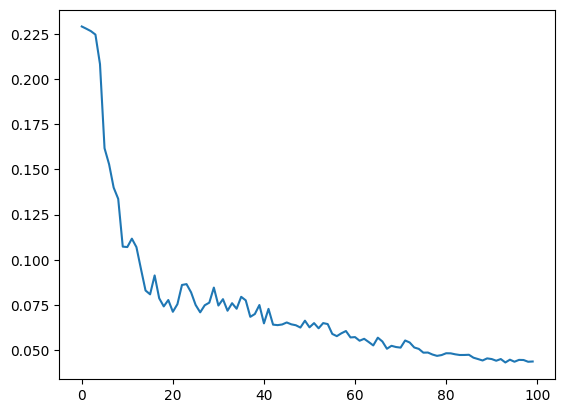

In [92]:
plt.plot(losses)

=== 4-Channel Communication Model Comparison ===


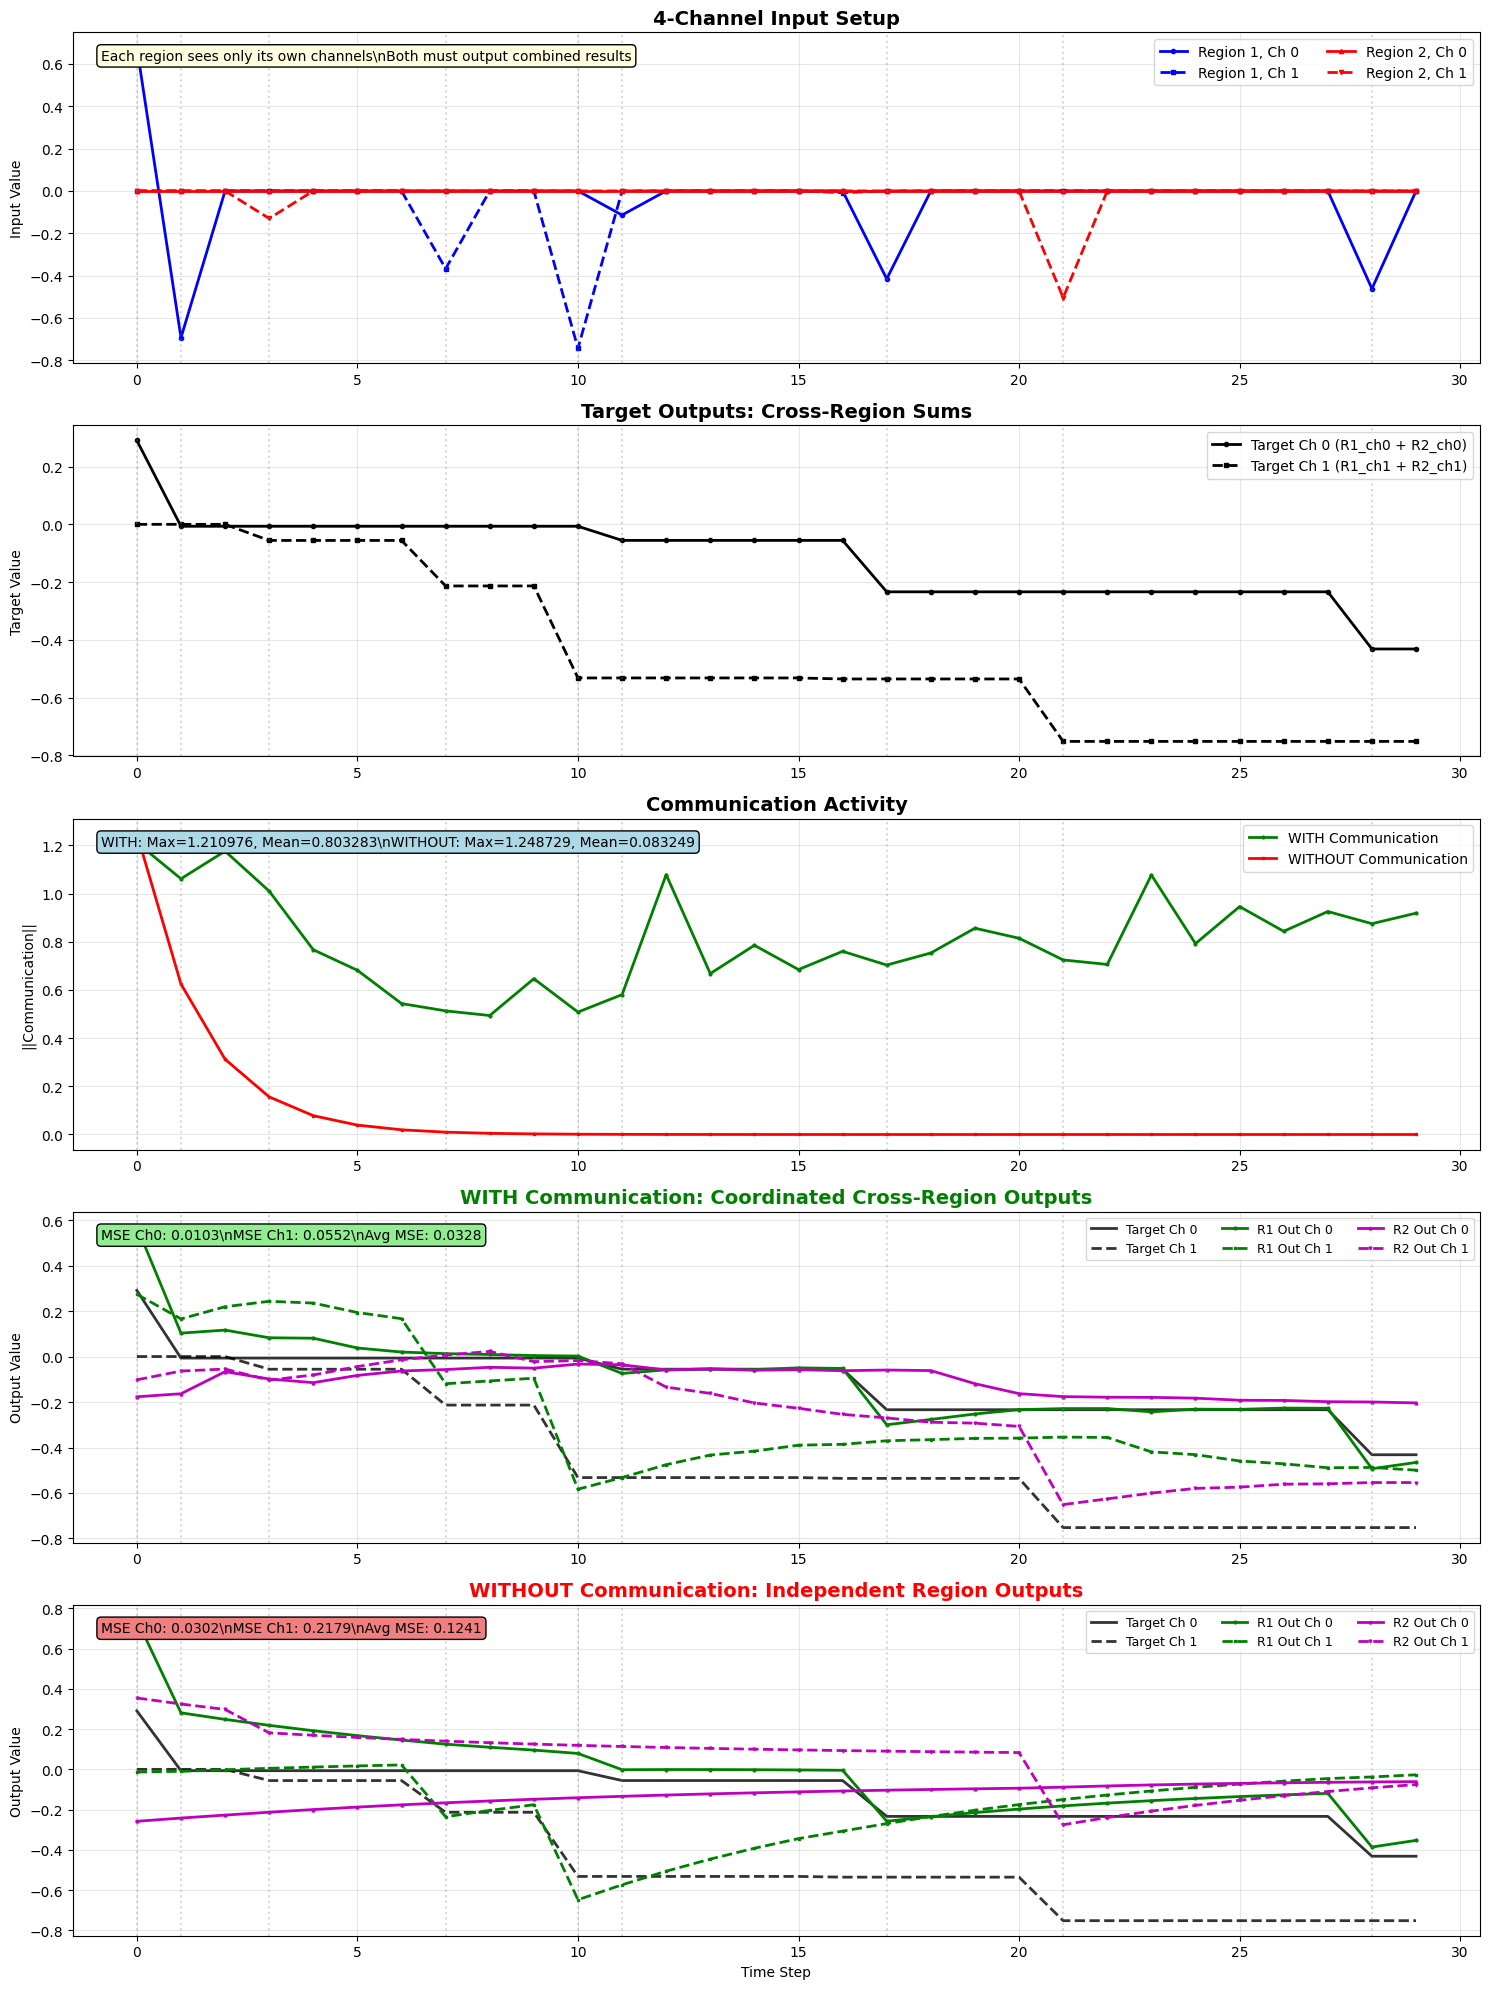

=== PERFORMANCE COMPARISON ===
MSE WITH communication:    0.032794
MSE WITHOUT communication: 0.124059
Improvement factor:        3.78x better
\n=== COMMUNICATION ANALYSIS ===
WITH communication - Mean: 0.80328300, Max: 1.21097636
WITHOUT communication - Mean: 0.08324859, Max: 1.24872875
Communication is ENABLED
Zero-comm enforcement is FAILED
\nPulse times: [0, 1, 3, 7, 10, 11, 17, 21, 28]
Total pulses: 9


In [103]:
def euler_step(model, h, x_t, dt=0.01):
    """Simple Euler integration step"""
    h_dot, comm_norm = model(h, x_t)
    h_new = h + dt * h_dot
    return h_new, comm_norm

def create_no_comm_model(original_model):
    """Create a copy of the model with communication disabled"""
    model_no_comm = MRgnODE_DynamicComm(
        N=original_model.N_regions, 
        input_dim=2,
        hidden_dim=32, 
        num_regions=original_model.num_regions, 
        comm_dim=16, tau_regions=0.01, tau_comm=0.01
    ).to(device)
    
    # Copy weights but zero out communication
    model_no_comm.load_state_dict(original_model.state_dict())
    
    # Zero out communication parameters
    with torch.no_grad():
        for param in model_no_comm.comm_flow_net.parameters():
            param.zero_()
        for param in model_no_comm.comm_gate_net.parameters():
            param.zero_()
        for param in model_no_comm.comm_to_region.parameters():
            param.zero_()
        model_no_comm.comm_signs.zero_()
    
    return model_no_comm

def visualize_communication_models(model_with_comm, trial_data, max_time=30):
    """
    Visualize how models with and without communication handle the 4-channel sum task
    """
    inputs, targets = trial_data
    max_time = min(max_time, inputs.shape[0])
    
    # Create model without communication
    model_no_comm = create_no_comm_model(model_with_comm)
    
    # Run model WITH communication
    model_with_comm.eval()
    inputs_tensor = torch.FloatTensor(inputs).unsqueeze(0).to(device)  # [1, time, regions, channels]
    
    h_with = torch.empty(1, model_with_comm.N_total, device=device)
    nn.init.xavier_uniform_(h_with)
    outputs_with_comm = []
    comm_magnitudes_with = []
    
    with torch.no_grad():
        for t in range(max_time):
            x_t = inputs_tensor[:, t]  # [1, regions, channels]
            h_with, comm_norm = euler_step(model_with_comm, h_with, x_t, 0.01)
            
            # Track communication magnitude
            comm_mag = comm_norm.item() if isinstance(comm_norm, torch.Tensor) else comm_norm
            comm_magnitudes_with.append(comm_mag)
            
            # Get region outputs - both channels for both regions
            region_outputs = model_with_comm.get_outputs(h_with)  # [1, regions, region_dim]
            outputs_with_comm.append([
                region_outputs[0, 0, 0].item(),  # Region 1 output channel 0
                region_outputs[0, 0, 1].item(),  # Region 1 output channel 1
                region_outputs[0, 1, 0].item(),  # Region 2 output channel 0
                region_outputs[0, 1, 1].item()   # Region 2 output channel 1
            ])
    
    # Run model WITHOUT communication
    model_no_comm.eval()
    
    h_without = torch.empty(1, model_no_comm.N_total, device=device)
    nn.init.xavier_uniform_(h_without)
    outputs_no_comm = []
    comm_magnitudes_without = []
    
    with torch.no_grad():
        for t in range(max_time):
            x_t = inputs_tensor[:, t]  # [1, regions, channels]
            h_without, comm_norm = euler_step(model_no_comm, h_without, x_t, 0.01)
            
            # Track communication magnitude (should be zero)
            comm_mag = comm_norm.item() if isinstance(comm_norm, torch.Tensor) else comm_norm
            comm_magnitudes_without.append(comm_mag)
            
            region_outputs = model_no_comm.get_outputs(h_without)  # [1, regions, region_dim]
            outputs_no_comm.append([
                region_outputs[0, 0, 0].item(),  # Region 1 output channel 0
                region_outputs[0, 0, 1].item(),  # Region 1 output channel 1
                region_outputs[0, 1, 0].item(),  # Region 2 output channel 0
                region_outputs[0, 1, 1].item()   # Region 2 output channel 1
            ])
    
    # Extract data for plotting
    times = np.arange(max_time)
    r1_ch0_inputs = inputs[:max_time, 0, 0]  # Region 1, Channel 0
    r1_ch1_inputs = inputs[:max_time, 0, 1]  # Region 1, Channel 1
    r2_ch0_inputs = inputs[:max_time, 1, 0]  # Region 2, Channel 0
    r2_ch1_inputs = inputs[:max_time, 1, 1]  # Region 2, Channel 1
    
    target_ch0 = targets[:max_time, 0, 0]  # Target: R1_ch0 + R2_ch0
    target_ch1 = targets[:max_time, 0, 1]  # Target: R1_ch1 + R2_ch1
    
    outputs_with_comm = np.array(outputs_with_comm)
    outputs_no_comm = np.array(outputs_no_comm)
    comm_magnitudes_with = np.array(comm_magnitudes_with)
    comm_magnitudes_without = np.array(comm_magnitudes_without)
    
    # Find pulse times for highlighting
    pulse_times = []
    for t in range(max_time):
        if (abs(r1_ch0_inputs[t]) > 0.01 or abs(r1_ch1_inputs[t]) > 0.01 or 
            abs(r2_ch0_inputs[t]) > 0.01 or abs(r2_ch1_inputs[t]) > 0.01):
            pulse_times.append(t)
    
    # Create the visualization
    fig, axes = plt.subplots(5, 1, figsize=(15, 20))
    
    # Plot 1: All Inputs
    axes[0].plot(times, r1_ch0_inputs, 'b-', linewidth=2, label='Region 1, Ch 0', marker='o', markersize=3)
    axes[0].plot(times, r1_ch1_inputs, 'b--', linewidth=2, label='Region 1, Ch 1', marker='s', markersize=3)
    axes[0].plot(times, r2_ch0_inputs, 'r-', linewidth=2, label='Region 2, Ch 0', marker='^', markersize=3)
    axes[0].plot(times, r2_ch1_inputs, 'r--', linewidth=2, label='Region 2, Ch 1', marker='v', markersize=3)
    
    # Highlight pulse times
    for pt in pulse_times:
        axes[0].axvline(x=pt, color='gray', alpha=0.3, linestyle=':')
    
    axes[0].set_title('4-Channel Input Setup', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Input Value')
    axes[0].legend(ncol=2)
    axes[0].grid(True, alpha=0.3)
    axes[0].text(0.02, 0.95, 'Each region sees only its own channels\\nBoth must output combined results', 
                transform=axes[0].transAxes, verticalalignment='top', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow"))
    
    # Plot 2: Target Outputs
    axes[1].plot(times, target_ch0, 'k-', linewidth=2, label='Target Ch 0 (R1_ch0 + R2_ch0)', marker='o', markersize=3)
    axes[1].plot(times, target_ch1, 'k--', linewidth=2, label='Target Ch 1 (R1_ch1 + R2_ch1)', marker='s', markersize=3)
    
    # Highlight pulse times
    for pt in pulse_times:
        axes[1].axvline(x=pt, color='gray', alpha=0.3, linestyle=':')
    
    axes[1].set_title('Target Outputs: Cross-Region Sums', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Target Value')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Plot 3: Communication Magnitudes
    axes[2].plot(times, comm_magnitudes_with, 'g-', linewidth=2, label='WITH Communication', marker='o', markersize=2)
    axes[2].plot(times, comm_magnitudes_without, 'r-', linewidth=2, label='WITHOUT Communication', marker='s', markersize=2)
    
    # Highlight pulse times
    for pt in pulse_times:
        axes[2].axvline(x=pt, color='gray', alpha=0.3, linestyle=':')
    
    axes[2].set_title('Communication Activity', fontsize=14, fontweight='bold')
    axes[2].set_ylabel('||Communication||')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    axes[2].text(0.02, 0.95, f'WITH: Max={np.max(comm_magnitudes_with):.6f}, Mean={np.mean(comm_magnitudes_with):.6f}\\nWITHOUT: Max={np.max(comm_magnitudes_without):.6f}, Mean={np.mean(comm_magnitudes_without):.6f}', 
                transform=axes[2].transAxes, verticalalignment='top', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))
    
    # Plot 4: Model WITH Communication
    axes[3].plot(times, target_ch0, 'k-', linewidth=2, label='Target Ch 0', alpha=0.8)
    axes[3].plot(times, target_ch1, 'k--', linewidth=2, label='Target Ch 1', alpha=0.8)
    axes[3].plot(times, outputs_with_comm[:, 0], 'g-', linewidth=2, label='R1 Out Ch 0', marker='o', markersize=2)
    axes[3].plot(times, outputs_with_comm[:, 1], 'g--', linewidth=2, label='R1 Out Ch 1', marker='s', markersize=2)
    axes[3].plot(times, outputs_with_comm[:, 2], 'm-', linewidth=2, label='R2 Out Ch 0', marker='^', markersize=2)
    axes[3].plot(times, outputs_with_comm[:, 3], 'm--', linewidth=2, label='R2 Out Ch 1', marker='v', markersize=2)
    
    # Highlight pulse times
    for pt in pulse_times:
        axes[3].axvline(x=pt, color='gray', alpha=0.3, linestyle=':')
    
    axes[3].set_title('WITH Communication: Coordinated Cross-Region Outputs', fontsize=14, fontweight='bold', color='green')
    axes[3].set_ylabel('Output Value')
    axes[3].legend(ncol=3, fontsize=9)
    axes[3].grid(True, alpha=0.3)
    
    # Calculate MSE for with communication
    mse_with_ch0 = np.mean((outputs_with_comm[:, [0,2]] - target_ch0.reshape(-1, 1))**2)
    mse_with_ch1 = np.mean((outputs_with_comm[:, [1,3]] - target_ch1.reshape(-1, 1))**2)
    mse_with = (mse_with_ch0 + mse_with_ch1) / 2
    axes[3].text(0.02, 0.95, f'MSE Ch0: {mse_with_ch0:.4f}\\nMSE Ch1: {mse_with_ch1:.4f}\\nAvg MSE: {mse_with:.4f}', 
                transform=axes[3].transAxes, verticalalignment='top', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen"))
    
    # Plot 5: Model WITHOUT Communication  
    axes[4].plot(times, target_ch0, 'k-', linewidth=2, label='Target Ch 0', alpha=0.8)
    axes[4].plot(times, target_ch1, 'k--', linewidth=2, label='Target Ch 1', alpha=0.8)
    axes[4].plot(times, outputs_no_comm[:, 0], 'g-', linewidth=2, label='R1 Out Ch 0', marker='o', markersize=2)
    axes[4].plot(times, outputs_no_comm[:, 1], 'g--', linewidth=2, label='R1 Out Ch 1', marker='s', markersize=2)
    axes[4].plot(times, outputs_no_comm[:, 2], 'm-', linewidth=2, label='R2 Out Ch 0', marker='^', markersize=2)
    axes[4].plot(times, outputs_no_comm[:, 3], 'm--', linewidth=2, label='R2 Out Ch 1', marker='v', markersize=2)
    
    # Highlight pulse times
    for pt in pulse_times:
        axes[4].axvline(x=pt, color='gray', alpha=0.3, linestyle=':')
    
    axes[4].set_title('WITHOUT Communication: Independent Region Outputs', fontsize=14, fontweight='bold', color='red')
    axes[4].set_xlabel('Time Step')
    axes[4].set_ylabel('Output Value')
    axes[4].legend(ncol=3, fontsize=9)
    axes[4].grid(True, alpha=0.3)
    
    # Calculate MSE for without communication
    mse_without_ch0 = np.mean((outputs_no_comm[:, [0,2]] - target_ch0.reshape(-1, 1))**2)
    mse_without_ch1 = np.mean((outputs_no_comm[:, [1,3]] - target_ch1.reshape(-1, 1))**2)
    mse_without = (mse_without_ch0 + mse_without_ch1) / 2
    axes[4].text(0.02, 0.95, f'MSE Ch0: {mse_without_ch0:.4f}\\nMSE Ch1: {mse_without_ch1:.4f}\\nAvg MSE: {mse_without:.4f}', 
                transform=axes[4].transAxes, verticalalignment='top', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral"))
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("=== PERFORMANCE COMPARISON ===")
    print(f"MSE WITH communication:    {mse_with:.6f}")
    print(f"MSE WITHOUT communication: {mse_without:.6f}")
    print(f"Improvement factor:        {mse_without/mse_with:.2f}x better")
    
    print("\\n=== COMMUNICATION ANALYSIS ===")
    print(f"WITH communication - Mean: {np.mean(comm_magnitudes_with):.8f}, Max: {np.max(comm_magnitudes_with):.8f}")
    print(f"WITHOUT communication - Mean: {np.mean(comm_magnitudes_without):.8f}, Max: {np.max(comm_magnitudes_without):.8f}")
    print(f"Communication is {'ENABLED' if np.max(comm_magnitudes_with) > 1e-6 else 'NOT WORKING'}")
    print(f"Zero-comm enforcement is {'WORKING' if np.max(comm_magnitudes_without) < 1e-8 else 'FAILED'}")
    
    print(f"\\nPulse times: {pulse_times}")
    print(f"Total pulses: {len(pulse_times)}")

def find_interesting_trial(data):
    """Find a trial with actual pulses"""
    for i, (inputs, targets) in enumerate(data[10:]):
        # Check if this trial has pulses
        if np.any(inputs > 0.01) or np.any(inputs < -0.01):
            pulse_count = np.sum(np.abs(inputs) > 0.01)
            print(f"Trial {i} has {pulse_count} pulse events")
            return inputs, targets
    return None, None

# Get a trial with pulses from your flip_flop_data
interesting_inputs, interesting_targets = flip_flop_data[30]

if interesting_inputs is not None:
    print("=== 4-Channel Communication Model Comparison ===")
    visualize_communication_models(model, (interesting_inputs, interesting_targets))
else:
    print("No trials with pulses found!")

=== SEPARATE REGION AND COMMUNICATION PHASE PORTRAITS ===
Creating separate phase portraits for each region and communication channel...
Model has 2 regions and 2 communication channels
Region 0 PCA explained variance: [0.9540718  0.04592815]
Region 1 PCA explained variance: [0.9541073  0.04589271]
Comm Channel 0 (R0→R1) PCA explained variance: [0.88539875 0.05280685 0.02682458]
Comm Channel 1 (R1→R0) PCA explained variance: [0.79841155 0.11726195 0.0354045 ]
Creating phase portrait for: Region 0
Creating phase portrait for: Region 1
Creating phase portrait for: Comm Ch0 (R0→R1)
Creating phase portrait for: Comm Ch1 (R1→R0)


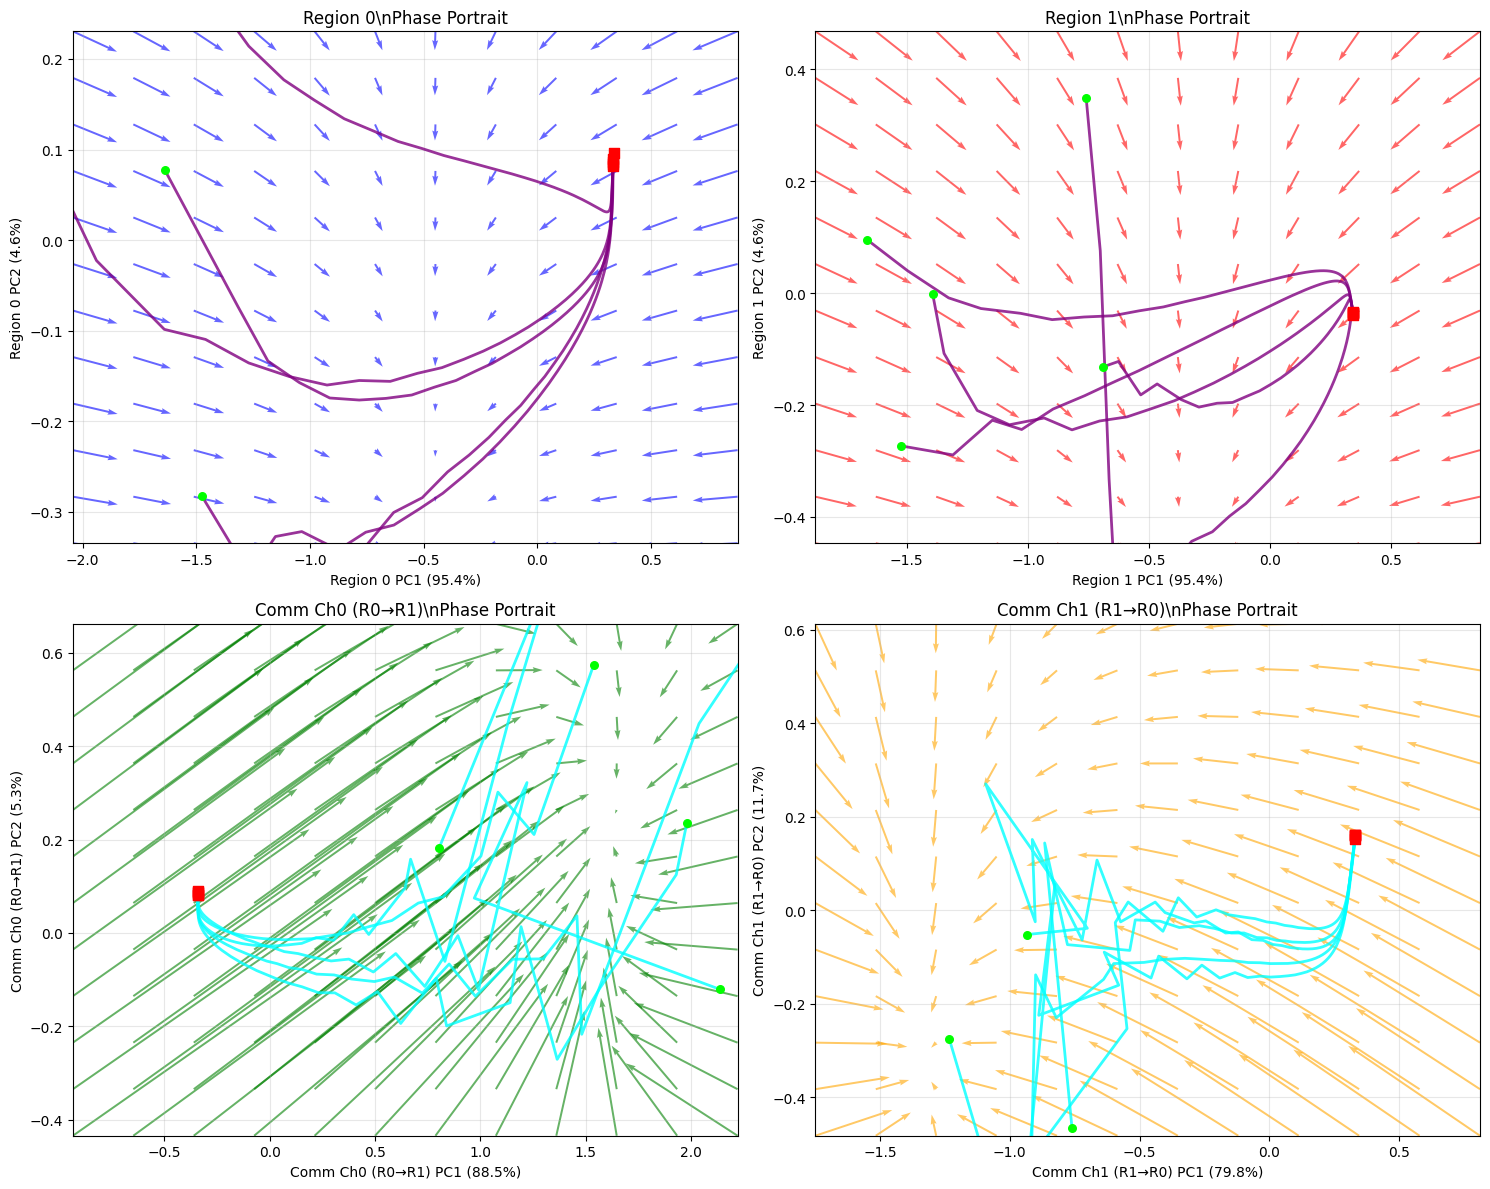

\n=== SEPARATE COMPONENT PHASE PORTRAITS ===
TOP LEFT: Region 0 dynamics
TOP RIGHT: Region 1 dynamics
BOTTOM LEFT: Communication Channel 0 (Region 0→1)
BOTTOM RIGHT: Communication Channel 1 (Region 1→0)
\nArrows: Flow fields for each component
Colored lines: Trajectories for each component
Lime dots: Trajectory starts
Red squares: Trajectory endpoints (attractors)


In [129]:
def create_separate_region_comm_phase_portraits(model, input_conditions=None, grid_size=8, n_trajectories=3):
    """
    Create separate phase portraits for each region and each communication channel
    """
    model.eval()
    device = next(model.parameters()).device
    
    if input_conditions is None:
        input_conditions = {
            # 'No Input': torch.zeros(1, 2, 2, device=device),
            # 'R0_Ch0 Pulse': torch.tensor([[[0.5, 0.0], [0.0, 0.0]]], device=device),
            # 'R1_Ch1 Pulse': torch.tensor([[[0.0, 0.0], [0.0, 0.5]]], device=device),
            'Both Pulses': torch.tensor([[[0.3, 0.0], [0.0, 0.3]]], device=device),
        }
    
    print("Creating separate phase portraits for each region and communication channel...")
    print(f"Model has {model.num_regions} regions and {model.num_comm_channels} communication channels")
    
    # Collect sample data for separate PCAs
    print("Collecting sample data for separate PCAs...")
    all_region0_states = []  # Region 0 only
    all_region1_states = []  # Region 1 only
    all_comm_ch0_states = []  # Region 0→1 communication
    all_comm_ch1_states = []  # Region 1→0 communication
    
    with torch.no_grad():
        for condition_name, input_pattern in input_conditions.items():
            for _ in range(15):
                h = torch.randn(1, model.N_total, device=device) * 0.2
                for step in range(50):
                    h_dot, _ = model(h, input_pattern, timestep=0)
                    h = h + 0.01 * h_dot
                    
                    h_regions, h_comm = model.partition_state(h)
                    
                    # Separate individual regions
                    if model.num_regions >= 1:
                        all_region0_states.append(h_regions[0, 0, :].detach().cpu().numpy())
                    if model.num_regions >= 2:
                        all_region1_states.append(h_regions[0, 1, :].detach().cpu().numpy())
                    
                    # Separate communication channels
                    if model.num_comm_channels >= 1:
                        all_comm_ch0_states.append(h_comm[0, 0, :].detach().cpu().numpy())
                    if model.num_comm_channels >= 2:
                        all_comm_ch1_states.append(h_comm[0, 1, :].detach().cpu().numpy())
    
    # Fit separate PCAs
    from sklearn.decomposition import PCA
    
    # Region PCAs
    region0_pca = None
    region1_pca = None
    
    if len(all_region0_states) > 0:
        all_region0_states = np.array(all_region0_states)
        region0_pca = PCA(n_components=min(3, all_region0_states.shape[1]))
        region0_pca.fit(all_region0_states)
        print(f"Region 0 PCA explained variance: {region0_pca.explained_variance_ratio_[:3]}")
    
    if len(all_region1_states) > 0:
        all_region1_states = np.array(all_region1_states)
        region1_pca = PCA(n_components=min(3, all_region1_states.shape[1]))
        region1_pca.fit(all_region1_states)
        print(f"Region 1 PCA explained variance: {region1_pca.explained_variance_ratio_[:3]}")
    
    # Communication PCAs
    comm_ch0_pca = None
    comm_ch1_pca = None
    
    if len(all_comm_ch0_states) > 0:
        all_comm_ch0_states = np.array(all_comm_ch0_states)
        comm_ch0_pca = PCA(n_components=min(3, all_comm_ch0_states.shape[1]))
        comm_ch0_pca.fit(all_comm_ch0_states)
        print(f"Comm Channel 0 (R0→R1) PCA explained variance: {comm_ch0_pca.explained_variance_ratio_[:3]}")
    
    if len(all_comm_ch1_states) > 0:
        all_comm_ch1_states = np.array(all_comm_ch1_states)
        comm_ch1_pca = PCA(n_components=min(3, all_comm_ch1_states.shape[1]))
        comm_ch1_pca.fit(all_comm_ch1_states)
        print(f"Comm Channel 1 (R1→R0) PCA explained variance: {comm_ch1_pca.explained_variance_ratio_[:3]}")
    
    # Create 2x2 grid of phase portraits for each input condition
    n_conditions = len(input_conditions)
    fig, big_axes = plt.subplots(2, 2, figsize=(15, 12))
    
    components = [
        ('Region 0', region0_pca, 'blue', big_axes[0, 0]),
        ('Region 1', region1_pca, 'red', big_axes[0, 1]),
        ('Comm Ch0 (R0→R1)', comm_ch0_pca, 'green', big_axes[1, 0]),
        ('Comm Ch1 (R1→R0)', comm_ch1_pca, 'orange', big_axes[1, 1])
    ]
    
    for comp_name, pca_model, color, ax in components:
        if pca_model is None:
            ax.text(0.5, 0.5, f'{comp_name}\\nNot Available', ha='center', va='center', 
                   transform=ax.transAxes, fontsize=14)
            ax.set_title(f'{comp_name} (N/A)')
            continue
            
        print(f"Creating phase portrait for: {comp_name}")
        
        # For simplicity, just show "Both Pulses" condition (most interesting)
        condition_name = 'Both Pulses'
        input_pattern = input_conditions[condition_name]
        
        # Determine which component we're analyzing
        if 'Region 0' in comp_name:
            region_idx = 0
            is_region = True
        elif 'Region 1' in comp_name:
            region_idx = 1
            is_region = True
        elif 'Ch0' in comp_name:
            comm_idx = 0
            is_region = False
        elif 'Ch1' in comp_name:
            comm_idx = 1
            is_region = False
        
        # Get sample data for bounds
        sample_states = []
        with torch.no_grad():
            for _ in range(20):
                h = torch.randn(1, model.N_total, device=device) * 0.3
                for step in range(100):
                    h_dot, _ = model(h, input_pattern, timestep=0)
                    h = h + 0.01 * h_dot
                    
                    h_regions, h_comm = model.partition_state(h)
                    
                    if is_region:
                        sample_states.append(h_regions[0, region_idx, :].detach().cpu().numpy())
                    else:
                        sample_states.append(h_comm[0, comm_idx, :].detach().cpu().numpy())
        
        sample_states = np.array(sample_states)
        sample_pca = pca_model.transform(sample_states)
        
        # Get bounds
        x_min, x_max = np.percentile(sample_pca[:, 0], [1,99])
        y_min, y_max = np.percentile(sample_pca[:, 1], [1,99])
        
        x_range = x_max - x_min
        y_range = y_max - y_min
        x_min, x_max = x_min - 0.3*x_range, x_max + 0.3*x_range
        y_min, y_max = y_min - 0.3*y_range, y_max + 0.3*y_range
        
        # Create flow field
        x_grid = np.linspace(x_min, x_max, grid_size)
        y_grid = np.linspace(y_min, y_max, grid_size)
        X, Y = np.meshgrid(x_grid, y_grid)
        U, V = np.zeros_like(X), np.zeros_like(Y)
        
        with torch.no_grad():
            for i in range(grid_size):
                for j in range(grid_size):
                    # Create point in PCA space
                    pca_point = np.array([X[i, j], Y[i, j], 0])[:pca_model.n_components_]
                    state = pca_model.inverse_transform(pca_point.reshape(1, -1))[0]
                    
                    # Create full model state
                    h_test = torch.zeros(1, model.N_total, device=device)
                    
                    if is_region:
                        # Set specific region state
                        region_start = region_idx * model.region_dim
                        h_test[0, region_start:region_start+model.region_dim] = torch.FloatTensor(state).to(device)
                    else:
                        # Set specific communication channel state
                        comm_start = model.N_regions + comm_idx * model.comm_dim
                        h_test[0, comm_start:comm_start+model.comm_dim] = torch.FloatTensor(state).to(device)
                    
                    # Compute dynamics
                    h_dot, _ = model(h_test, input_pattern, timestep=0)
                    
                    # Extract relevant component dynamics
                    h_regions_dot, h_comm_dot = model.partition_state(h_dot)
                    
                    if is_region:
                        component_dot = h_regions_dot[0, region_idx, :].detach().cpu().numpy()
                    else:
                        component_dot = h_comm_dot[0, comm_idx, :].detach().cpu().numpy()
                    
                    # Transform to PCA space
                    component_dot_pca = pca_model.transform(component_dot.reshape(1, -1))[0]
                    
                    U[i, j] = component_dot_pca[0]
                    V[i, j] = component_dot_pca[1]
        
        # Plot flow field
        if "ch" in comp_name.lower():
            ax.quiver(X, Y, U, V, alpha=0.6, scale=800, width=0.003, color=color)

        else:
            ax.quiver(X, Y, U, V, alpha=0.6, scale=300, width=0.003, color=color)
        
        # Add trajectories
        with torch.no_grad():
            for traj_idx in range(n_trajectories):
                h = torch.randn(1, model.N_total, device=device) * 0.3
                trajectory_pca = []
                
                for step in range(150):
                    h_dot, _ = model(h, input_pattern, timestep=0)
                    h = h + 0.01 * h_dot
                    
                    h_regions, h_comm = model.partition_state(h)
                    
                    if is_region:
                        component_state = h_regions[0, region_idx, :].detach().cpu().numpy()
                    else:
                        component_state = h_comm[0, comm_idx, :].detach().cpu().numpy()
                    
                    component_pca_state = pca_model.transform(component_state.reshape(1, -1))[0]
                    trajectory_pca.append(component_pca_state)
                
                trajectory_pca = np.array(trajectory_pca)
                
                # Use different colors for trajectories
                traj_color = 'purple' if is_region else 'cyan'
                ax.plot(trajectory_pca[:, 0], trajectory_pca[:, 1], 
                       traj_color, alpha=0.8, linewidth=2)
                ax.scatter(trajectory_pca[0, 0], trajectory_pca[0, 1], 
                          color='lime', s=30, zorder=5)
                ax.scatter(trajectory_pca[-1, 0], trajectory_pca[-1, 1], 
                          color='red', s=50, marker='s', zorder=5)
        
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_xlabel(f'{comp_name} PC1 ({pca_model.explained_variance_ratio_[0]:.1%})')
        ax.set_ylabel(f'{comp_name} PC2 ({pca_model.explained_variance_ratio_[1]:.1%})')
        ax.set_title(f'{comp_name}\\nPhase Portrait')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\\n=== SEPARATE COMPONENT PHASE PORTRAITS ===")
    print("TOP LEFT: Region 0 dynamics")
    print("TOP RIGHT: Region 1 dynamics") 
    print("BOTTOM LEFT: Communication Channel 0 (Region 0→1)")
    print("BOTTOM RIGHT: Communication Channel 1 (Region 1→0)")
    print("\\nArrows: Flow fields for each component")
    print("Colored lines: Trajectories for each component")
    print("Lime dots: Trajectory starts")
    print("Red squares: Trajectory endpoints (attractors)")
    
    return region0_pca, region1_pca, comm_ch0_pca, comm_ch1_pca

# Run separate component phase portrait analysis
print("=== SEPARATE REGION AND COMMUNICATION PHASE PORTRAITS ===")
region0_pca, region1_pca, comm_ch0_pca, comm_ch1_pca = create_separate_region_comm_phase_portraits(model, grid_size=12, n_trajectories=5)